# Task

# Column-by-Column Explanation

## Session & Timestamps
* **`session_id`** – Unique identifier for the user session.
* **`session_dt`** – Date and time when the session started.
* **`conversion_dt`** – Timestamp of conversion (time of payment received).
* **`conversion_payout`** – Payout value associated with a successful conversion.
* **`conversion_type`** – Type/category of conversion event.

---

## Funnel Answers (User-Provided Inputs)
> *Note: These fields are duplicated for each brand shown in the session.*

* **`annual_income`** – User's self-reported yearly income range.
* **`credit_line`** – User's self-reported credit line.
* **`credit_score_rate`** – User’s credit score category.
* **`currently_have_mortgage`** – User’s current mortgage status.
* **`loan_primary_purpose`** – User’s purpose for seeking a HELOC/loan.
* **`military_veteran`** – Whether the user is a military veteran.
* **`property_type`** – Type of property (e.g., Single-Family).
* **`property_use`** – How the property is used (Primary Residence, etc.).
* **`property_value`** – Estimated property value range.
* **`zipcode`** – User-provided ZIP code.

---

## Brand Display Information (Offer-Level)
* **`brand`** – The brand of the offer shown to the user.
* **`position`** – The order in which this brand appeared in the session.
* **`offer_click`** – Whether the user clicked this specific brand offer.

---

## Marketing Source (Paid Media Metadata)
* **`vertical`** – Vertical/category (e.g., HELOC).
* **`account_id`** – Advertising account ID (matches 1-to-1 to the vertical in this dataset).
* **`account_name`** – Name of the advertising account.
* **`campaign_id`** – ID of the campaign the ad belongs to.
* **`campaign_name`** – Name of the campaign.
* **`adset_id`** – ID of the ad set within the campaign.
* **`adset_name`** – Name of the ad set.
* **`ad_id`** – ID of the specific ad that the user saw.
* **`ad_name`** – Name/label for the ad creative.
* **`traffic_source`** – Source platform (e.g., Facebook).

---

## Session Context
* **`page`** – Page URL where the session took place.
* **`device_type`** – User device type (mobile/desktop/tablet).
* **`city`** – User’s city (IP-based).
* **`state`** – User’s state (IP-based).
* **`country`** – User’s country (IP-based).

---

My notes:
    
- It can be described as LTR problem, however
 - we have click fact as relevance
    - we have historic ordering 
    - we have conversion payout
- but I cannot see the variety of other items per one session so that the model learn how to actually rank them

# Business problem

The goal is to optimize the ordering of offers (brands) shown to a user session in order to maximize expected revenue, where revenue depends on both user interaction (clicks) and downstream conversion payout.

## Data understanding

In [116]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [317]:
path = 'data/data_final.csv'
sessions = pd.read_csv(path)

In [318]:
# Sort in more meaningful way
sessions = sessions.sort_values(by=['session_id', 'position'])

In [216]:
sessions.head(3)

,session_id,annual_income,credit_line,credit_score_rate,currently_have_mortgage,loan_primary_purpose,military_veteran,property_type,property_use,property_value,zipcode,session_dt,conversion_dt,conversion_payout,conversion_type,brand,vertical,account_id,account_name,campaign_id,campaign_name,adset_id,adset_name,ad_id,ad_name,traffic_source,page,device_type,city,country,state,position,offer_click
20995,00041b27-c2f8-4978-b85d-c94e7d7b6d47,$50K–$75K,The Maximum Amount I&#039;m Eligible for,Good (620-779),"Yes, $250K - $400K left to pay",Home Improvements,Yes,Single-Family Home,Primary Residence,"$400,000 - $600,000",NaN,2025-10-30T01:21:30.000Z,NaN,NaN,NaN,amerisave,Home Equity Loans,332412632590552,PL - Schemathics,120235148710520617,HELOC VA - 589888,120235148710560617,VA,120235893179790617,6221123795,facebook,https://top10us.com/app/heloc-v5,mobile,South Bend,United States,Indiana,1,0
28255,00041b27-c2f8-4978-b85d-c94e7d7b6d47,$50K–$75K,The Maximum Amount I&#039;m Eligible for,Good (620-779),"Yes, $250K - $400K left to pay",Home Improvements,Yes,Single-Family Home,Primary Residence,"$400,000 - $600,000",NaN,2025-10-30T01:21:30.000Z,NaN,NaN,NaN,achieve,Home Equity Loans,332412632590552,PL - Schemathics,120235148710520617,HELOC VA - 589888,120235148710560617,VA,120235893179790617,6221123795,facebook,https://top10us.com/app/heloc-v5,mobile,South Bend,United States,Indiana,2,0
28535,00041b27-c2f8-4978-b85d-c94e7d7b6d47,$50K–$75K,The Maximum Amount I&#039;m Eligible for,Good (620-779),"Yes, $250K - $400K left to pay",Home Improvements,Yes,Single-Family Home,Primary Residence,"$400,000 - $600,000",NaN,2025-10-30T01:21:30.000Z,NaN,NaN,NaN,moneygroupgood,Home Equity Loans,332412632590552,PL - Schemathics,120235148710520617,HELOC VA - 589888,120235148710560617,VA,120235893179790617,6221123795,facebook,https://top10us.com/app/heloc-v5,mobile,South Bend,United States,Indiana,3,0


In [217]:
sessions.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 60628 entries, 20995 to 41311
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   session_id               60628 non-null  object 
 1   annual_income            32909 non-null  object 
 2   credit_line              35702 non-null  object 
 3   credit_score_rate        60588 non-null  object 
 4   currently_have_mortgage  60591 non-null  object 
 5   loan_primary_purpose     60553 non-null  object 
 6   military_veteran         25260 non-null  object 
 7   property_type            60369 non-null  object 
 8   property_use             60510 non-null  object 
 9   property_value           60574 non-null  object 
 10  zipcode                  931 non-null    float64
 11  session_dt               60628 non-null  object 
 12  conversion_dt            4456 non-null   object 
 13  conversion_payout        4456 non-null   float64
 14  conversion_type   

## Data Cleansing

In [319]:
na_ratios = sessions.isna().sum()/sessions.shape[0]

na_ratios[na_ratios > 0].sort_values(ascending=False)

zipcode                    0.984644
conversion_dt              0.926503
conversion_type            0.926503
conversion_payout          0.926503
military_veteran           0.583361
annual_income              0.457198
credit_line                0.411130
account_id                 0.145428
account_name               0.145428
campaign_name              0.145428
adset_name                 0.145428
ad_name                    0.145428
city                       0.006977
state                      0.006977
property_type              0.004272
property_use               0.001946
loan_primary_purpose       0.001237
country                    0.001122
property_value             0.000891
credit_score_rate          0.000660
currently_have_mortgage    0.000610
dtype: float64

In [320]:
nuniques = sessions.nunique()

nuniques[nuniques < 2]

conversion_type    1
dtype: int64

In [276]:
sessions['zipcode'].nunique()

391

In [321]:
# Drop 2 columns
# zipcode since it almost empty + useless in training (391 unique values + many new on inference for sure)
# conversion type has only one value
to_drop = ['zipcode', 'conversion_type']

sessions = sessions.drop(columns=to_drop)

In [257]:
sessions.columns

Index(['session_id', 'annual_income', 'credit_line', 'credit_score_rate',
       'currently_have_mortgage', 'loan_primary_purpose', 'military_veteran',
       'property_type', 'property_use', 'property_value', 'zipcode',
       'session_dt', 'conversion_dt', 'conversion_payout', 'conversion_type',
       'brand', 'vertical', 'account_id', 'account_name', 'campaign_id',
       'campaign_name', 'adset_id', 'adset_name', 'ad_id', 'ad_name',
       'traffic_source', 'page', 'device_type', 'city', 'country', 'state',
       'position', 'offer_click'],
      dtype='object')

In [207]:
user_features = ['annual_income', 'credit_line', 'credit_score_rate',
 'currently_have_mortgage', 'loan_primary_purpose', 'military_veteran',
 'property_type', 'property_use', 'property_value']

In [215]:
sessions[user_features].head(3)

,annual_income,credit_line,credit_score_rate,currently_have_mortgage,loan_primary_purpose,military_veteran,property_type,property_use,property_value
20995,$50K–$75K,The Maximum Amount I&#039;m Eligible for,Good (620-779),"Yes, $250K - $400K left to pay",Home Improvements,Yes,Single-Family Home,Primary Residence,"$400,000 - $600,000"
28255,$50K–$75K,The Maximum Amount I&#039;m Eligible for,Good (620-779),"Yes, $250K - $400K left to pay",Home Improvements,Yes,Single-Family Home,Primary Residence,"$400,000 - $600,000"
28535,$50K–$75K,The Maximum Amount I&#039;m Eligible for,Good (620-779),"Yes, $250K - $400K left to pay",Home Improvements,Yes,Single-Family Home,Primary Residence,"$400,000 - $600,000"


In [266]:
# Categorical data
sessions['annual_income'].value_counts(dropna=False, normalize=True)

Unknown           0.457198
Over $100K        0.180098
Less than $50K    0.130237
$50K–$75K         0.121693
$75K–$100K        0.110774
Name: annual_income, dtype: float64

In [219]:
sessions['credit_line'].value_counts(dropna=False, normalize=True)

NaN                                         0.411130
Up to $50K                                  0.183908
The Maximum Amount I&#039;m Eligible for    0.145692
$50K - $100K                                0.137692
$100K - $200K                               0.080507
$300,000-$500,000                           0.033038
$50,000-$100,000                            0.002722
$100,000-$200,000                           0.002045
Under $50,000                               0.001880
$200,000-$300,000                           0.001385
Name: credit_line, dtype: float64

In [220]:
sessions['credit_score_rate'].value_counts(dropna=False, normalize=True)

Fair (580-649)           0.252787
Good (620-779)           0.198803
Fair (580-619)           0.140084
Good (650-719)           0.127730
Excellent (Above 720)    0.120769
Excellent (Above 780)    0.086379
Poor (500-579)           0.061836
Very Poor (Under 500)    0.010820
NaN                      0.000660
Bueno (620-779)          0.000132
Name: credit_score_rate, dtype: float64

In [232]:
for feat in user_features:
    print(f'Unique values for col {feat}: {", ".join(sorted([str(x) for x in sessions[feat].unique()]))}\n')

Unique values for col annual_income: $50K–$75K, $75K–$100K, Less than $50K, Over $100K, nan

Unique values for col credit_line: $100,000-$200,000, $100K - $200K, $200,000-$300,000, $300,000-$500,000, $50,000-$100,000, $50K - $100K, The Maximum Amount I&#039;m Eligible for, Under $50,000, Up to $50K, nan

Unique values for col credit_score_rate: Bueno (620-779), Excellent (Above 720), Excellent (Above 780), Fair (580-619), Fair (580-649), Good (620-779), Good (650-719), Poor (500-579), Very Poor (Under 500), nan

Unique values for col currently_have_mortgage: No Mortgage, Sí, me quedan menos de 100.000 dólares por pagar., Sí, quedan entre $100.000 y $250.000 por pagar., Yes, $100K - $250K left to pay, Yes, $250K - $400K left to pay, Yes, Between $50K-$150K left to pay, Yes, More than $400K left to pay, Yes, Over $150K left to pay, Yes, Under $100K left to pay, Yes, Under $50K left to pay, nan

Unique values for col loan_primary_purpose: Consolidación de deuda, Debt Consolidation, Home I

In [239]:
sessions.drop_duplicates(subset=['session_id'])['credit_score_rate'].value_counts()

Fair (580-649)           5330
Good (620-779)           3073
Good (650-719)           2416
Fair (580-619)           2396
Poor (500-579)           2204
Excellent (Above 720)    2018
Excellent (Above 780)    1133
Very Poor (Under 500)     361
Bueno (620-779)             2
Name: credit_score_rate, dtype: int64

In [336]:
import re

def clean_credit_score(val):
    if pd.isna(val):
        return 'Unknown'
    
    # Remove everything inside parentheses
    val = re.sub(r'\(.*?\)', '', val).strip()
    mapp = {'Bueno': 'Good'}
    
    return mapp.get(val, val)
    
sessions['credit_score_rate'] = sessions['credit_score_rate'].apply(lambda x: clean_credit_score(x))

In [337]:
sessions.drop_duplicates(subset=['session_id'])['currently_have_mortgage'].value_counts()

$100K-$250K    5731
No             5595
Under $100K    4269
$250K-$400K    2257
$400K+          947
$50K-$150K       52
$150K+           46
Under $50K       37
Name: currently_have_mortgage, dtype: int64

In [332]:
# Mortgage Status 
mortgage_map = {
    'No Mortgage': 'No',
    'Sí, me quedan menos de 100.000 dólares por pagar.': 'Under $100K',
    'Yes, Under $100K left to pay': 'Under $100K',
    'Yes, Under $50K left to pay': 'Under $50K', 
    'Sí, quedan entre $100.000 y $250.000 por pagar.': '$100K-$250K',
    'Yes, $100K - $250K left to pay': '$100K-$250K',
    'Yes, Between $50K-$150K left to pay': '$50K-$150K',
    'Yes, $250K - $400K left to pay': '$250K-$400K',
    'Yes, More than $400K left to pay': '$400K+',
    'Yes, Over $150K left to pay': '$150K+'}

sessions['currently_have_mortgage'] = sessions['currently_have_mortgage'].replace(mortgage_map)

sessions.drop_duplicates(subset=['session_id'])['currently_have_mortgage'].value_counts()

$100K-$250K    5731
No             5595
Under $100K    4269
$250K-$400K    2257
$400K+          947
$50K-$150K       52
$150K+           46
Under $50K       37
Name: currently_have_mortgage, dtype: int64

In [333]:
# Credit line
credit_line_map = {
    '$50K - $100K': '$50,000-$100,000',
    '$100K - $200K': '$100,000-$200,000',
    'Up to $50K': 'Under $50,000',
    'The Maximum Amount I&#039;m Eligible for': 'Maximum Eligible'
}
sessions['credit_line'] = sessions['credit_line'].replace(credit_line_map)

sessions.drop_duplicates(subset=['session_id'])['credit_line'].value_counts()

Under $50,000        3542
$50,000-$100,000     2432
Maximum Eligible     2364
$100,000-$200,000    1364
$300,000-$500,000     576
$200,000-$300,000      24
Name: credit_line, dtype: int64

In [334]:
sessions.drop_duplicates(subset=['session_id'])['loan_primary_purpose'].value_counts()

Home Improvements           8443
Debt Consolidation          5690
Other                       2785
Investment Opportunities    1136
Retirement Income            869
Mejoras en el hogar            1
Consolidación de deuda         1
Name: loan_primary_purpose, dtype: int64

In [335]:
# Clean property and purpose
sessions['loan_primary_purpose'] = sessions['loan_primary_purpose'].replace({
    'Consolidación de deuda': 'Debt Consolidation',
    'Mejoras en el hogar': 'Home Improvements'
})

sessions['property_type'] = sessions['property_type'].replace({'Vivienda unifamiliar': 'Single-Family Home'})
sessions['property_use'] = sessions['property_use'].replace({'Residencia principal': 'Primary Residence'})

In [262]:
sessions['military_veteran'].unique()

array(['Yes', 'Unknown', 'No'], dtype=object)

In [272]:
for feat in user_features:
    print(f'Unique values for col {feat}: {sessions[feat].value_counts()}\n')

Unique values for col annual_income: Unknown           27719
Over $100K        10919
Less than $50K     7896
$50K–$75K          7378
$75K–$100K         6716
Name: annual_income, dtype: int64

Unique values for col credit_line: Unknown              24926
Under $50,000        11264
Maximum Eligible      8833
$50,000-$100,000      8513
$100,000-$200,000     5005
$300,000-$500,000     2003
$200,000-$300,000       84
Name: credit_line, dtype: int64

Unique values for col credit_score_rate: Fair         23819
Good         19805
Excellent    12559
Poor          3749
Very Poor      656
Unknown         40
Name: credit_score_rate, dtype: int64

Unique values for col currently_have_mortgage: $100K-$250K    18676
No             18181
Under $100K    12561
$250K-$400K     7607
$400K+          3201
$50K-$150K       139
$150K+           119
Under $50K       107
Unknown           37
Name: currently_have_mortgage, dtype: int64

Unique values for col loan_primary_purpose: Home Improvements           2754

### encoding

In [338]:
# Ordinal encoding features

annual_income_map = {
    "Less than $50K": 1,
    "$50K–$75K": 2,
    "$75K–$100K": 3,
    "Over $100K": 4
}


credit_score_rate_map = {
    "Very Poor": 1,
    "Poor": 2,
    "Fair": 3,
    "Good": 4,
    "Excellent": 5
}

# Some of the values in the following categories can be unified because of close meaning and they are quite rare
credit_line_map = {
    "Under $50,000": 1,
    "$50,000-$100,000": 2,
    "$100,000-$200,000": 3,
    "$200,000-$300,000": 4,
    "$300,000-$500,000": 4,
    "Maximum Eligible": 6
}

property_value_map = {
    "Under $150,000": 1,
    "Under $200,000": 1,
    "$150,000 - $300,000": 2, 
    "$200,000 - $400,000": 2,
    "$300,000 - $500,000": 3,
    "$400,000 - $600,000": 3,
    "$600,000 - $800,000": 7,
    "$500,000 - $1M": 7,
    "Over $800,000": 8,
    "Over $1M": 8
}

sessions["annual_income_ord"] = sessions["annual_income"].map(annual_income_map)
sessions["credit_score_ord"] = sessions["credit_score_rate"].map(credit_score_rate_map)
sessions["credit_line_ord"] = sessions["credit_line"].map(credit_line_map)
sessions["property_value_ord"] = sessions["property_value"].map(property_value_map)

In [479]:
sessions.drop_duplicates(subset=['session_id'])['currently_have_mortgage'].value_counts(dropna=False)

$100K-$250K    5731
No             5595
Under $100K    4269
$250K-$400K    2257
$400K+          947
$50K-$150K       52
$150K+           46
Under $50K       37
NaN              14
Name: currently_have_mortgage, dtype: int64

In [477]:
mortgage_mapping = {
         'No': 1,
         'Under $50K': 2,
         'Under $100K': 2,
         '$50K-$150K': 2, # Under 150k
         '$100K-$250K': 3,
         '$150K+': 3,
         '$250K-$400K': 4,
         '$400K+': 5,
        }

sessions["mortgage_ord"] = sessions["currently_have_mortgage"].map(mortgage_mapping)

sessions["mortgage_ord"] = sessions["mortgage_ord"].fillna(1) # Fillna as "No"

In [259]:
sessions[user_features] = sessions[user_features].fillna('Unknown')

# EDA

## Session level analysis

In [64]:
# around 19k unique sessions/users
sessions['session_id'].nunique()

18948

In [46]:
# Only 121 ads
sessions['ad_id'].nunique()

121

In [97]:
# 23 brands to order
sessions['brand'].nunique()

23

In [26]:
# Up to 7 offers per session
sessions['position'].describe()

count    60628.000000
mean         2.380385
std          1.269560
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max          7.000000
Name: position, dtype: float64

In [32]:
# Small numbers of obvesvations per positions greater than 3
sessions['position'].value_counts(normalize=True)

1    0.315085
2    0.271178
3    0.211387
4    0.134245
5    0.057366
6    0.010193
7    0.000544
Name: position, dtype: float64

In [86]:
# 23 brands
sessions['brand'].nunique()

23

In [70]:
# How many clicks per session possible?
clicks_per_session = sessions.groupby(['session_id', 'position'])['offer_click'].max()

avg_clicks = clicks_per_session.mean()
max_clicks = clicks_per_session.max()
zero_click_sessions = (clicks_per_session == 0).sum()

print(f"Average clicks per session: {avg_clicks}")
print(f"Max clicks in a single session: {max_clicks}")
print(f"Sessions with zero clicks: {zero_click_sessions}")

Average clicks per session: 0.6811272957568081
Max clicks in a single session: 6
Sessions with zero clicks: 6632


In [60]:
clicks_per_session[clicks_per_session == 6].index.values[0]

'eb6bb6b1-12ba-4595-a3db-e4ea4c1e2ce0'

In [61]:
# 6 clicks per session_id, however in fact there are only 2 clicks per same offer
# one brand can appear several times per session with different timestamps of the conversion
sessions[sessions['session_id'] == clicks_per_session[clicks_per_session == 6].index.values[0]]

,session_id,annual_income,credit_line,credit_score_rate,currently_have_mortgage,loan_primary_purpose,military_veteran,property_type,property_use,property_value,zipcode,session_dt,conversion_dt,conversion_payout,conversion_type,brand,vertical,account_id,account_name,campaign_id,campaign_name,adset_id,adset_name,ad_id,ad_name,traffic_source,page,device_type,city,country,state,position,offer_click
9452,eb6bb6b1-12ba-4595-a3db-e4ea4c1e2ce0,Over $100K,$100K - $200K,Fair (580-649),"Yes, $100K - $250K left to pay",Other,NaN,Single-Family Home,Primary Residence,"$400,000 - $600,000",NaN,2025-10-21T13:34:45.000Z,NaN,NaN,NaN,pointfair,Home Equity Loans,NaN,NaN,1840727532096785,NaN,1840727532096801,NaN,1843312479503393,NaN,tiktok,https://top10us.com/app/heloc-v5,mobile,Pomona,United States,California,1,0
24773,eb6bb6b1-12ba-4595-a3db-e4ea4c1e2ce0,Over $100K,$100K - $200K,Fair (580-649),"Yes, $100K - $250K left to pay",Other,NaN,Single-Family Home,Primary Residence,"$400,000 - $600,000",NaN,2025-10-21T13:36:14.000Z,2025-10-21T13:43:28.000Z,100.0,click,unlock,Home Equity Loans,6999982062639824898,Topusmoney,1840727532096785,58995,1840727532096801,good-credit-v1,1843312479503393,6211143246,tiktok,https://top10us.com/app/heloc-v5,mobile,Pomona,United States,California,2,1
32233,eb6bb6b1-12ba-4595-a3db-e4ea4c1e2ce0,Over $100K,$100K - $200K,Fair (580-649),"Yes, $100K - $250K left to pay",Other,NaN,Single-Family Home,Primary Residence,"$400,000 - $600,000",NaN,2025-10-21T13:36:14.000Z,2025-11-14T23:17:50.000Z,0.0,click,unlock,Home Equity Loans,6999982062639824898,Topusmoney,1840727532096785,58995,1840727532096801,good-credit-v1,1843312479503393,6211143246,tiktok,https://top10us.com/app/heloc-v5,mobile,Pomona,United States,California,2,1
47387,eb6bb6b1-12ba-4595-a3db-e4ea4c1e2ce0,Over $100K,$100K - $200K,Fair (580-649),"Yes, $100K - $250K left to pay",Other,NaN,Single-Family Home,Primary Residence,"$400,000 - $600,000",NaN,2025-10-21T13:36:14.000Z,2025-10-24T15:27:43.000Z,0.0,click,unlock,Home Equity Loans,6999982062639824898,Topusmoney,1840727532096785,58995,1840727532096801,good-credit-v1,1843312479503393,6211143246,tiktok,https://top10us.com/app/heloc-v5,mobile,Pomona,United States,California,2,1
54739,eb6bb6b1-12ba-4595-a3db-e4ea4c1e2ce0,Over $100K,$100K - $200K,Fair (580-649),"Yes, $100K - $250K left to pay",Other,NaN,Single-Family Home,Primary Residence,"$400,000 - $600,000",NaN,2025-10-21T13:36:14.000Z,2025-10-30T16:53:37.000Z,0.0,click,unlock,Home Equity Loans,6999982062639824898,Topusmoney,1840727532096785,58995,1840727532096801,good-credit-v1,1843312479503393,6211143246,tiktok,https://top10us.com/app/heloc-v5,mobile,Pomona,United States,California,2,1
54986,eb6bb6b1-12ba-4595-a3db-e4ea4c1e2ce0,Over $100K,$100K - $200K,Fair (580-649),"Yes, $100K - $250K left to pay",Other,NaN,Single-Family Home,Primary Residence,"$400,000 - $600,000",NaN,2025-10-21T13:36:14.000Z,2025-11-24T18:32:29.000Z,0.0,click,unlock,Home Equity Loans,6999982062639824898,Topusmoney,1840727532096785,58995,1840727532096801,good-credit-v1,1843312479503393,6211143246,tiktok,https://top10us.com/app/heloc-v5,mobile,Pomona,United States,California,2,1
32530,eb6bb6b1-12ba-4595-a3db-e4ea4c1e2ce0,Over $100K,$100K - $200K,Fair (580-649),"Yes, $100K - $250K left to pay",Other,NaN,Single-Family Home,Primary Residence,"$400,000 - $600,000",NaN,2025-10-21T13:34:45.000Z,NaN,NaN,NaN,newamericanfunding,Home Equity Loans,NaN,NaN,1840727532096785,NaN,1840727532096801,NaN,1843312479503393,NaN,tiktok,https://top10us.com/app/heloc-v5,mobile,Pomona,United States,California,3,0
1848,eb6bb6b1-12ba-4595-a3db-e4ea4c1e2ce0,Over $100K,$100K - $200K,Fair (580-649),"Yes, $100K - $250K left to pay",Other,NaN,Single-Family Home,Primary Residence,"$400,000 - $600,000",NaN,2025-10-21T13:34:45.000Z,NaN,NaN,NaN,moneygroupfair,Home Equity Loans,NaN,NaN,1840727532096785,NaN,1840727532096801,NaN,1843312479503393,NaN,tiktok,https://top10us.com/app/heloc-v5,mobile,Pomona,United States,California,4,0
1924,eb6b

In [114]:
# Dropped position duplicates
dropped_posdup = sessions.drop_duplicates(subset=['session_id', 'position'])

# Verify there is one brand per one position
dropped_posdup.groupby(['session_id', 'position'])['brand'].count().max()

1

In [85]:
# Exclude cases with duplicated positions per session and check out the click distribution
# Max 4 clicks per session for unique brands
clicks_per_session = sessions.drop_duplicates(subset=['session_id', 'position']).groupby(['session_id'])['offer_click'].sum()

avg_clicks = clicks_per_session.mean()
max_clicks = clicks_per_session.max()
zero_click_sessions = (clicks_per_session == 0).sum()

print(f"Average clicks per session: {avg_clicks}")
print(f"Max clicks in a single session: {max_clicks}")
print(f"Sessions with zero clicks: {zero_click_sessions}")

Average clicks per session: 0.6726303567658856
Max clicks in a single session: 4
Sessions with zero clicks: 6636


In [750]:
# Investigate are the cases with several clicks and several payouts
payout_sessions = dropped_posdup[dropped_posdup['conversion_payout'] > 0].groupby('session_id').agg(
    {'offer_click': sum})

# There are cases with several clicks and different payouts per one session
sessions[sessions['session_id'].isin(payout_sessions[payout_sessions['offer_click'] > 1].index)].head(10)

,session_id,annual_income,credit_line,credit_score_rate,currently_have_mortgage,loan_primary_purpose,military_veteran,property_type,property_use,property_value,session_dt,conversion_dt,conversion_payout,brand,vertical,account_id,account_name,campaign_id,campaign_name,adset_id,adset_name,ad_id,ad_name,traffic_source,page,device_type,city,country,state,position,offer_click,annual_income_ord,credit_score_ord,credit_line_ord,property_value_ord,mortgage_ord
22011,152375f7-61e2-41d7-bc8d-bfbfb8f9c172,Less than $50K,"Under $50,000",Excellent,$100K-$250K,Home Improvements,NaN,Single-Family Home,Primary Residence,"$200,000 - $400,000",2025-10-21T17:41:21.000Z,NaN,NaN,amerisave,Home Equity Loans,NaN,NaN,120217681620720617,NaN,120231060083620617,NaN,120234668563710617,NaN,facebook,https://top10us.com/app/heloc-v5,desktop,Mentor,United States,Ohio,1,0,1.0,5.0,1.0,2.0,3.0
44799,152375f7-61e2-41d7-bc8d-bfbfb8f9c172,Less than $50K,"Under $50,000",Excellent,$100K-$250K,Home Improvements,NaN,Single-Family Home,Primary Residence,"$200,000 - $400,000",2025-10-21T17:41:45.000Z,2025-10-21T17:46:17.000Z,150.0,aven,Home Equity Loans,332412632590552,PL - Schemathics,120217681620720617,HELOC - 5890,120231060083620617,Static-ads,120234668563710617,6221123672,facebook,https://top10us.com/app/heloc-v5,desktop,Mentor,United States,Ohio,2,1,1.0,5.0,1.0,2.0,3.0
59596,152375f7-61e2-41d7-bc8d-bfbfb8f9c172,Less than $50K,"Under $50,000",Excellent,$100K-$250K,Home Improvements,NaN,Single-Family Home,Primary Residence,"$200,000 - $400,000",2025-10-21T17:47:17.000Z,2025-10-21T17:49:04.000Z,90.0,achieve,Home Equity Loans,332412632590552,PL - Schemathics,120217681620720617,HELOC - 5890,120231060083620617,Static-ads,120234668563710617,6221123672,facebook,https://top10us.com/app/heloc-v5,desktop,Mentor,United States,Ohio,3,1,1.0,5.0,1.0,2.0,3.0
6790,152375f7-61e2-41d7-bc8d-bfbfb8f9c172,Less than $50K,"Under $50,000",Excellent,$100K-$250K,Home Improvements,NaN,Single-Family Home,Primary Residence,"$200,000 - $400,000",2025-10-21T17:41:21.000Z,NaN,NaN,quickenloans,Home Equity Loans,NaN,NaN,120217681620720617,NaN,120231060083620617,NaN,120234668563710617,NaN,facebook,https://top10us.com/app/heloc-v5,desktop,Mentor,United States,Ohio,4,0,1.0,5.0,1.0,2.0,3.0
29315,152375f7-61e2-41d7-bc8d-bfbfb8f9c172,Less than $50K,"Under $50,000",Excellent,$100K-$250K,Home Improvements,NaN,Single-Family Home,Primary Residence,"$200,000 - $400,000",2025-10-21T17:41:21.000Z,NaN,NaN,moneygroupexcellent,Home Equity Loans,NaN,NaN,120217681620720617,NaN,120231060083620617,NaN,120234668563710617,NaN,facebook,https://top10us.com/app/heloc-v5,desktop,Mentor,United States,Ohio,5,0,1.0,5.0,1.0,2.0,3.0
37135,152375f7-61e2-41d7-bc8d-bfbfb8f9c172,Less than $50K,"Under $50,000",Excellent,$100K-$250K,Home Improvements,NaN,Single-Family Home,Primary Residence,"$200,000 - $400,000",2025-10-21T17:41:21.000Z,NaN,NaN,lendingtree,Home Equity Loans,NaN,NaN,120217681620720617,NaN,120231060083620617,NaN,120234668563710617,NaN,facebook,https://top10us.com/app/heloc-v5,desktop,Mentor,United States,Ohio,6,0,1.0,5.0,1.0,2.0,3.0
46358,178f8bb1-1297-48e4-a548-5a032a03b8d2,$75K–$100K,"$50,000-$100,000",Good,$100K-$250K,Home Improvements,NaN,Single-Family Home,Primary Residence,"$200,000 - $400,000",2025-10-22T19:40:11.000Z,2025-10-22T19:42:11.000Z,90.0,amerisave,Home Equity Loans,332412632590552,PL - Schemathics,120217681620720617,HELOC - 5890,120234803929500617,Static-ads-620,120234803929530617,6221233718,facebook,https://top10us.com/app/heloc-v5,mobile,Jefferson City,United States,Missouri,1,1,3.0,4.0,2.0,2.0,3.0
46265,178f8bb1-1297-48e4-a548-5a032a03b8d2,$75K–$100K,"$50,000-$100,000",Good,$100K-$250K,Home Improvements,NaN,Single-Family Home,Primary Residence,"$200,000 - $400,000",2025-10-22T19:45:49.000Z,2025-10-22T19:48:56.000Z,60.0,quickenloans,Home Equity Loans,332412632590552,PL - Schemathics,120217681620720617,HELOC - 5890,120234803929500617,Static-ads-620,120234803929530617,6221233718,facebook,https://top10us.

In [115]:
# 35% of session have no clicks
zero_click_sessions/sessions['session_id'].nunique()

0.35022165927802407

In [95]:
# 0/1 clicks is 98% of the cases
click_distribution = clicks_per_session.value_counts(normalize=True).sort_index() * 100
print(click_distribution)

0    35.022166
1    62.887904
2     1.910492
3     0.163606
4     0.015833
Name: offer_click, dtype: float64


Click Statistics by Position:
   position  total_displays  total_clicks       ctr
0         1           19103          9428  0.493535
1         2           16441          2032  0.123593
2         3           12816           878  0.068508
3         4            8139           436  0.053569
4         5            3478           124  0.035653
5         6             618             6  0.009709
6         7              33             2  0.060606


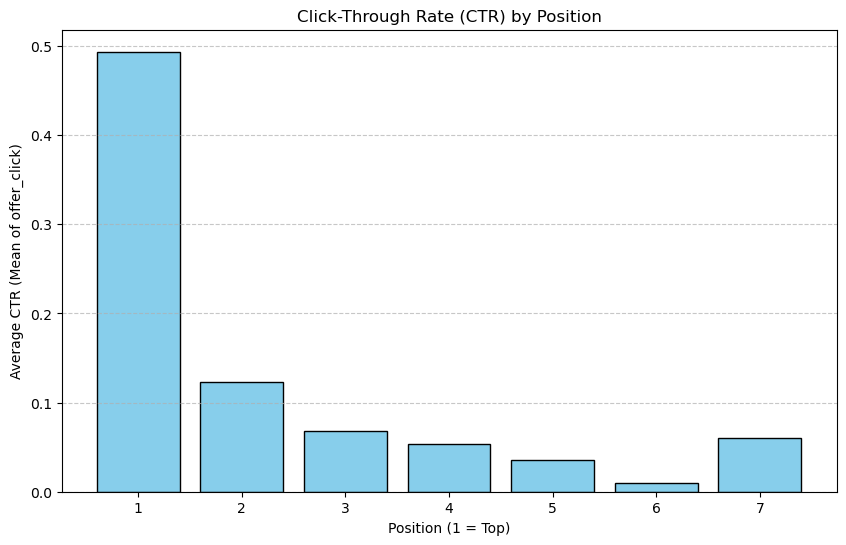

In [117]:
# Calculate CTR and Volume per position
position_stats = sessions.groupby('position').agg(
    total_displays=('offer_click', 'count'),
    total_clicks=('offer_click', 'sum'),
    ctr=('offer_click', 'mean')
).reset_index()

# Display the numerical results
print("Click Statistics by Position:")
print(position_stats)

# Visualize the Position Bias
plt.figure(figsize=(10, 6))
plt.bar(position_stats['position'], position_stats['ctr'], color='skyblue', edgecolor='black')
plt.title('Click-Through Rate (CTR) by Position')
plt.xlabel('Position (1 = Top)')
plt.ylabel('Average CTR (Mean of offer_click)')
plt.xticks(position_stats['position'])
plt.grid(axis='y', linestyle='--', alpha=0.7)

### Conclusion/insights

- Position bias: the first position receives nearly 50% CTR, while others disproportionally much lower. It might mean that clicks are influenced by position rather than offer quality/user preferences. It should be taken into consideration during modelling
- 98% of the sessions have either zero or one click, while the maximum number of clicks per session is 4
- there are duplicate brands per one session with varying conversion dt timestamp
-  There are cases with several clicks and different payouts per one session (So several levels of relevance should be created later)

## Marketing/brand EDA

### CTR by brands

In [154]:
sessions['conversion_payout'].isna().mean()

0.9265026060566075

In [158]:
sessions[sessions['offer_click'] == 1]['conversion_payout'].isna().mean()

0.6556640322330699

I want to look at the CTR & payouts by brands

In [144]:
# Which brands make 99% of the traffic
brand_stats = brand_stats.sort_values('total_displays', ascending=False)

# Calculate ratios and cumulative percentage
brand_stats['displays_ratio'] = brand_stats['total_displays'] / brand_stats['total_displays'].sum()
brand_stats['cumulative_traffic'] = brand_stats['displays_ratio'].cumsum()

# Filter for brands that make up the top 99%
top_99_percent_brands = brand_stats[brand_stats['cumulative_traffic'] <= 0.99]

# Identify the "Long Tail" (the bottom 1%)
long_tail_brands = brand_stats[brand_stats['cumulative_traffic'] > 0.99]

print(f"Total unique brands: {len(brand_stats)}")
print(f"Number of brands driving 99% of traffic: {len(top_99_percent_brands)}")
print(f"Number of brands in the 'Long Tail' (bottom 1%): {len(long_tail_brands)}")

Total unique brands: 23
Number of brands driving 99% of traffic: 15
Number of brands in the 'Long Tail' (bottom 1%): 8


In [149]:
dropped_posdup['conversion_payout'] = dropped_posdup['conversion_payout'].fillna(0)

# Aggregate metrics by brand
brand_stats = dropped_posdup.groupby('brand').agg(
    total_displays=('brand', 'count'),
    total_clicks=('offer_click', 'sum'),
    total_payout=('conversion_payout', 'sum')
).reset_index()

# Calculate KPI Ratios
brand_stats['ctr'] = brand_stats['total_clicks'] / brand_stats['total_displays']
brand_stats['payout_per_click'] = brand_stats.apply(lambda x: x['total_payout'] / x['total_clicks'] if x['total_clicks'] > 0 else 0, axis=1)
brand_stats['payout_per_display'] = brand_stats['total_payout'] / brand_stats['total_displays']


brand_stats.sort_values(by=['total_displays', 'total_clicks'], ascending=False)

/var/folders/w7/dqy1s6xd201_wrdd9ylkrmt40000gn/T/ipykernel_81448/725102904.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dropped_posdup['conversion_payout'] = dropped_posdup['conversion_payout'].fillna(0)


,brand,total_displays,total_clicks,total_payout,ctr,payout_per_click,payout_per_display
8,lendingtree,15785,2412,35150.00,0.152803,14.572968,2.226798
1,amerisave,7651,2822,123752.00,0.368841,43.852587,16.174618
0,achieve,5501,806,22230.00,0.146519,27.580645,4.041083
16,pointfair,3631,1364,27300.00,0.375654,20.014663,7.518590
11,moneygroupgood,3428,336,6175.40,0.098016,18.379167,1.801459
14,newamericanfunding,3270,606,9900.00,0.185321,16.336634,3.027523
6,figure,3145,613,31100.00,0.194913,50.734095,9.888712
21,unlock,3110,703,3175.00,0.226045,4.516358,1.020900
10,moneygroupfair,2689,318,7323.40,0.118260,23.029560,2.723466
22,upstart,2590,852,10880.00,0.328958,12.769953,4.200772


In [165]:
top_99_percent_brands = top_99_percent_brands.reset_index(drop=True)

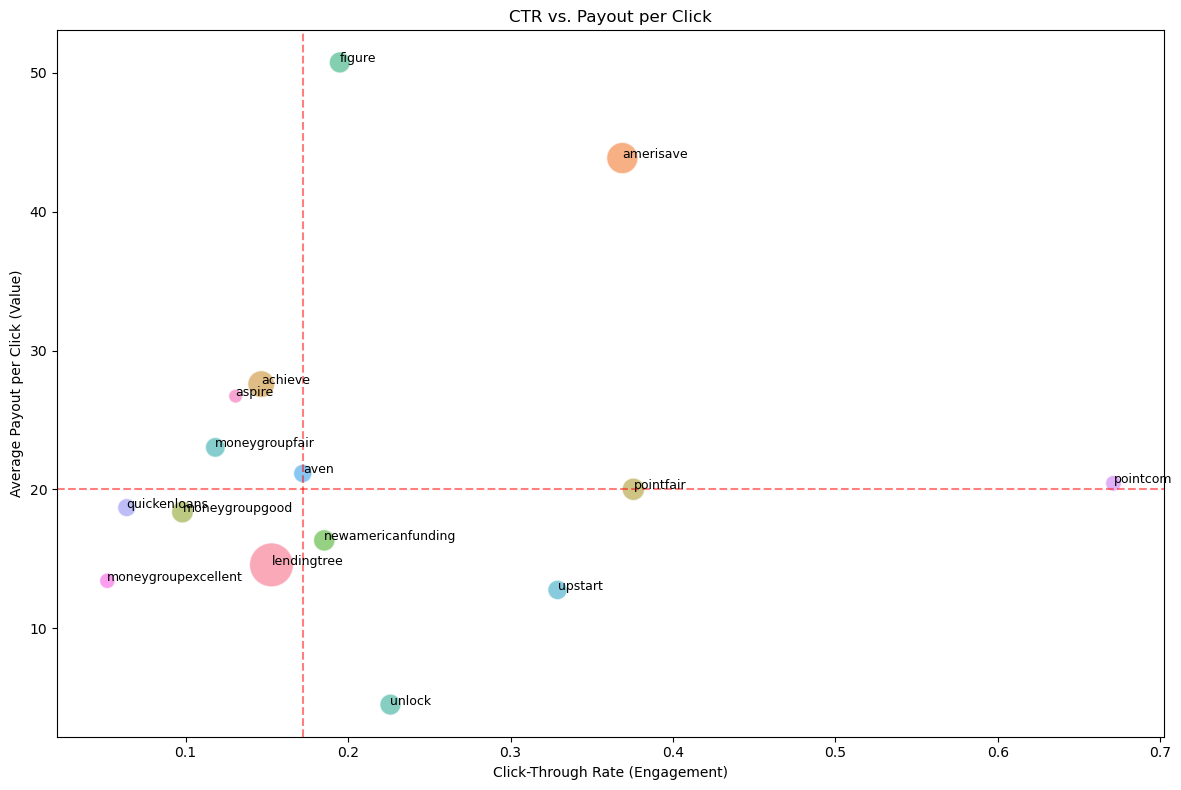

In [172]:
# CTR vs Payout only for top contributors
plt.figure(figsize=(12, 8))
sns.scatterplot(a
    data=top_99_percent_brands, 
    x='ctr', 
    y='payout_per_click', 
    size='total_displays', 
    hue='brand', 
    legend=False,
    sizes=(100, 1000),
    alpha=0.6
)

# Add quadrant lines (using medians as thresholds)
plt.axvline(top_99_percent_brands['ctr'].median(), color='red', linestyle='--', alpha=0.5)
plt.axhline(top_99_percent_brands['payout_per_click'].median(), color='red', linestyle='--', alpha=0.5)

plt.title('CTR vs. Payout per Click')
plt.xlabel('Click-Through Rate (Engagement)')
plt.ylabel('Average Payout per Click (Value)')

# Label the brands for clarity
for i in range(top_99_percent_brands.shape[0]):
    plt.text(top_99_percent_brands.ctr[i], top_99_percent_brands.payout_per_click[i], top_99_percent_brands.brand[i], fontsize=9)

plt.tight_layout()
plt.show()

### brands + position

In [176]:
# CTR per brand per position
brand_pos_performance = dropped_posdup.groupby(['brand', 'position']).agg(
    impressions=('offer_click', 'count'),
    clicks=('offer_click', 'sum')
).reset_index()

brand_pos_performance['ctr'] = brand_pos_performance['clicks'] / brand_pos_performance['impressions']
significant_data = brand_pos_performance[brand_pos_performance['impressions'] > 100]

# pivot table for heatmap
pivot_ctr = significant_data.pivot(index='brand', columns='position', values='ctr')

Text(145.72222222222223, 0.5, 'Brand')

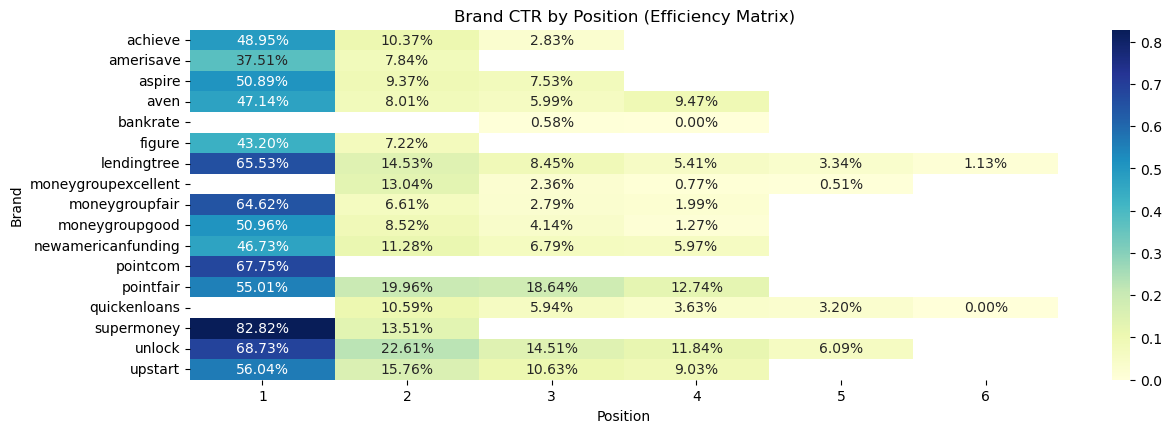

In [192]:
# Heatmap of CTR
plt.figure(figsize=(14, 10))

plt.subplot(2, 1, 1)
sns.heatmap(pivot_ctr, annot=True, fmt=".2%", cmap="YlGnBu")
plt.title('Brand CTR by Position (Efficiency Matrix)')
plt.xlabel('Position')
plt.ylabel('Brand')

In [194]:
# Calculate average position and frequency for each brand
brand_pos_bias = sessions.groupby('brand').agg(
    avg_position=('position', 'mean'),
    total_appearances=('position', 'count'),
    min_pos=('position', 'min'),
    max_pos=('position', 'max')
).reset_index().sort_values('avg_position')

# Some of the brands consistenly shown in lower positions
brand_pos_bias.sort_values(by=['total_appearances', 'avg_position'], ascending=False).head(10)

,brand,avg_position,total_appearances,min_pos,max_pos
8,lendingtree,3.137411,15843,1,7
1,amerisave,1.024295,7697,1,5
0,achieve,2.146297,5523,1,3
16,pointfair,1.717120,3680,1,5
11,moneygroupgood,2.736735,3449,1,5
14,newamericanfunding,2.141947,3297,1,5
21,unlock,2.876967,3178,1,7
6,figure,1.674913,3153,1,3
10,moneygroupfair,2.663479,2719,1,5
22,upstart,1.909827,2595,1,4


Insights:

- 8 long tail brands that conributed to less that 1% of the traffic
- Some of the brands like "lendingtree" have significantly lower avg position (3.13), however show top performing ctr on positions number 1
    - While some of the brands vice versa, have lower than median ctr on position number 1, but have higher avg position, for instance "figure"
- Likely some brands are more premium, while others target weaker profile and pay lower payouts (investigate later on user level EDA)

## User level EDA

Now we want to check how user features are related to CTR

In [288]:
def compute_ctr(df, col):
    agg = (
        df.groupby(col)["offer_click"]
        .agg(["mean", "count"])
        .rename(columns={"mean": "ctr", "count": "n"})
        .reset_index()
        .sort_values(col)
    )
    return agg

In [343]:
# In order to explore users we don't want to take into account duplicate data
unique_sessions = sessions.drop_duplicates(subset=['session_id'])

In [344]:
def prepare_plot_df(df, original_col, encoded_col):
    tmp = df[[original_col, encoded_col, "offer_click"]].copy()
    
    # Compute CTR per original category
    agg = (
        tmp.groupby([encoded_col, original_col])["offer_click"]
        .agg(["mean", "count"])
        .rename(columns={"mean": "ctr", "count": "n"})
        .reset_index()
    )
    
    # For overlapping encoded values pick first
    agg = agg.sort_values([encoded_col, "n"], ascending=[True, False])
    agg = agg.groupby(encoded_col).first().reset_index()
    
    return agg.sort_values(encoded_col)


income_df = prepare_plot_df(unique_sessions, "annual_income", "annual_income_ord")
credit_score_df = prepare_plot_df(unique_sessions, "credit_score_rate", "credit_score_ord")
credit_line_df = prepare_plot_df(unique_sessions, "credit_line", "credit_line_ord")
property_value_df = prepare_plot_df(unique_sessions, "property_value", "property_value_ord")

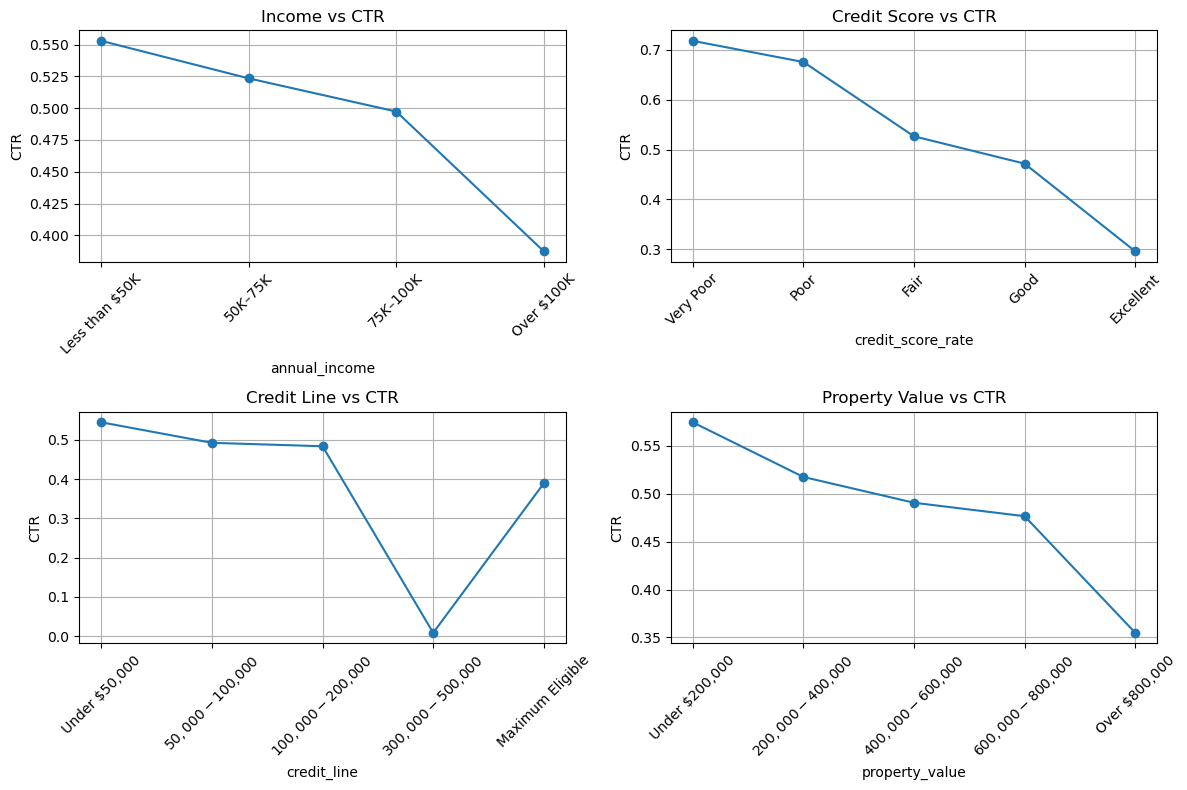

In [345]:
def plot_ctr(ax, df_ctr, label_col, title):
    ax.plot(df_ctr[label_col], df_ctr["ctr"], marker="o")
    ax.set_xlabel(label_col)
    ax.set_ylabel("CTR")
    ax.set_title(title)
    ax.grid(True)
    ax.tick_params(axis='x', rotation=45)


fig, axes = plt.subplots(2, 2, figsize=(12, 8))

plot_ctr(axes[0, 0], income_df, "annual_income", "Income vs CTR")
plot_ctr(axes[0, 1], credit_score_df, "credit_score_rate", "Credit Score vs CTR")
plot_ctr(axes[1, 0], credit_line_df, "credit_line", "Credit Line vs CTR")
plot_ctr(axes[1, 1], property_value_df, "property_value", "Property Value vs CTR")

plt.tight_layout()
plt.show()

In [356]:
income_df[["annual_income_ord", "ctr"]].corr(method='spearman').iloc[0, 1]

-1.0

In [358]:
credit_score_df[["credit_score_ord", "ctr"]].corr(method='spearman').iloc[0, 1]

-1.0

In [359]:
credit_line_df[["credit_line_ord", "ctr"]].corr(method='spearman').iloc[0, 1]

-0.9

In [364]:
property_value_df[["property_value_ord", "ctr"]].corr(method='spearman').iloc[0, 1]

-1.0

### User/brands

We want to investigate the interaction between user cohorts and the brands preferences if there any

In [368]:
# Pick credit score rate with the lowest na ratio
unique_sessions[user_features].isna().mean()

annual_income              0.501636
credit_line                0.456301
credit_score_rate          0.000000
currently_have_mortgage    0.000739
loan_primary_purpose       0.001214
military_veteran           0.638062
property_type              0.004539
property_use               0.001847
property_value             0.000897
dtype: float64

In [377]:
# CTRs per brands+credit score
interaction = (
    unique_sessions.groupby(["credit_score_ord", "credit_score_rate", "brand"])["offer_click"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "ctr", "count": "n"})
    .reset_index()
)

# at least 100 samples
interaction = interaction[interaction["n"] > 100]

In [380]:
# Baseline CTR per brands
brand_avg = unique_sessions.groupby("brand")["offer_click"].mean()

interaction["lift"] = interaction.apply(
    lambda x: x["ctr"] / brand_avg[x["brand"]],
    axis=1
)

In [383]:
# For heatmaps
pivot_ctr = interaction.pivot(
    index="credit_score_ord",
    columns="brand",
    values="ctr"
)

pivot_lift = interaction.pivot(
    index="credit_score_ord",
    columns="brand",
    values="lift"
)

In [387]:
interaction

,credit_score_ord,credit_score_rate,brand,ctr,n,lift
3,1.0,Very Poor,pointcom,0.642857,168,0.948886
4,1.0,Very Poor,supermoney,0.836735,147,1.010280
9,2.0,Poor,lendingtree,0.644156,770,0.982669
10,2.0,Poor,pointcom,0.681783,1279,1.006342
14,2.0,Poor,unlock,0.788618,123,1.144768
15,3.0,Fair,achieve,0.418919,222,0.855740
16,3.0,Fair,amerisave,0.443009,1316,1.180937
18,3.0,Fair,figure,0.405312,866,0.938157
19,3.0,Fair,lendingtree,0.659509,978,1.006091
20,3.0,Fair,moneygroupfair,0.648045,358,1.002793


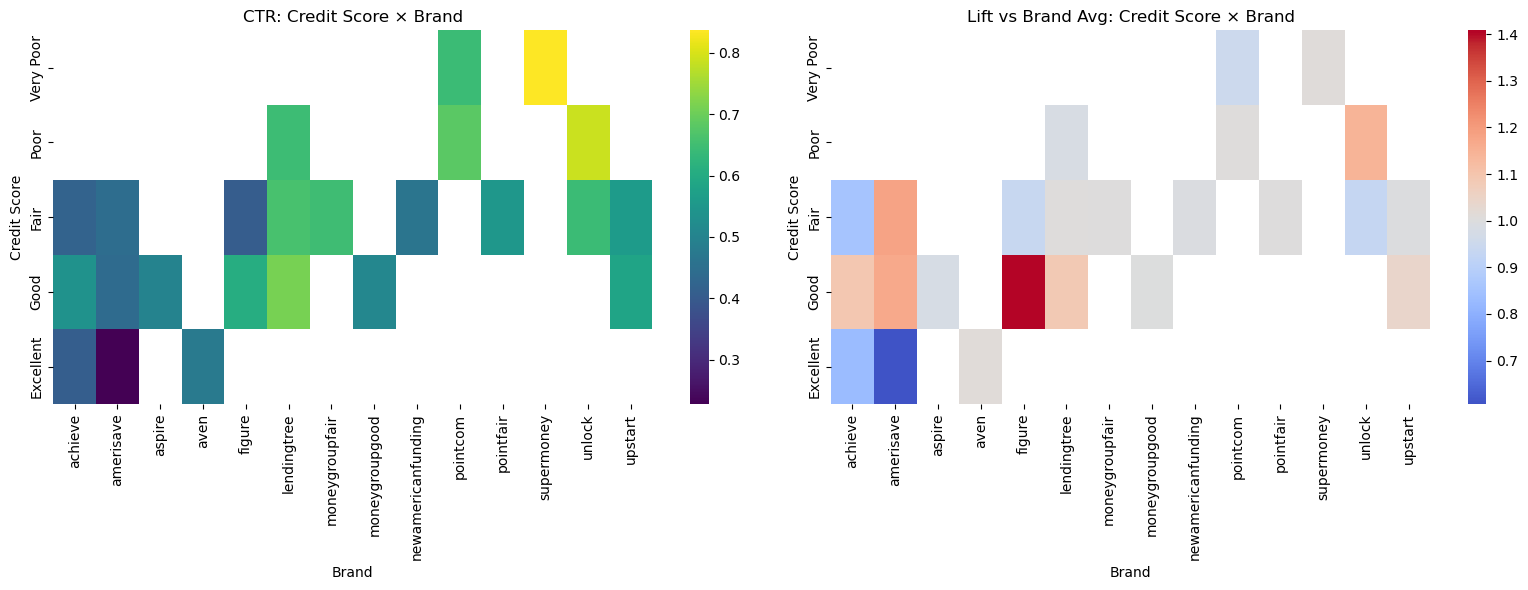

In [385]:
labels_map = (
    unique_sessions[["credit_score_ord", "credit_score_rate"]]
    .dropna()
    .drop_duplicates()
    .sort_values("credit_score_ord")
    .groupby("credit_score_ord")
    .first()["credit_score_rate"]
)

pivot_ctr.index = pivot_ctr.index.map(labels_map)
pivot_lift.index = pivot_lift.index.map(labels_map)

# -----------------------------
# 7. Plot
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(pivot_ctr, cmap="viridis", ax=axes[0])
axes[0].set_title("CTR: Credit Score × Brand")
axes[0].set_xlabel("Brand")
axes[0].set_ylabel("Credit Score")

sns.heatmap(pivot_lift, cmap="coolwarm", center=1.0, ax=axes[1])
axes[1].set_title("Lift vs Brand Avg: Credit Score × Brand")
axes[1].set_xlabel("Brand")
axes[1].set_ylabel("Credit Score")

plt.tight_layout()
plt.show()

#### Brands x users x payout

In [404]:
# Agg to get metrics
unique_sessions["clicked"] = unique_sessions["offer_click"] == 1
unique_sessions["is_converted"] = unique_sessions["conversion_payout"].notna()
unique_sessions["payout_filled"] = unique_sessions["conversion_payout"].fillna(0)

agg = (
    unique_sessions.groupby(["credit_score_ord", "credit_score_rate", "brand"])
    .apply(lambda x: pd.Series({
        "ctr": x["clicked"].mean(),
        "n": len(x),
        # conditional on click
        "conv_rate_given_click": x.loc[x["clicked"], "is_converted"].mean(),
        "payout_per_click": x.loc[x["clicked"], "payout_filled"].mean(),
        "payout_mean_converted": x.loc[x["is_converted"], "payout_filled"].mean()
        
    }))
    .reset_index()
)

/var/folders/w7/dqy1s6xd201_wrdd9ylkrmt40000gn/T/ipykernel_81448/1687937767.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  unique_sessions["clicked"] = unique_sessions["offer_click"] == 1
/var/folders/w7/dqy1s6xd201_wrdd9ylkrmt40000gn/T/ipykernel_81448/1687937767.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  unique_sessions["is_converted"] = unique_sessions["conversion_payout"].notna()
/var/folders/w7/dqy1s6xd201_wrdd9ylkrmt40000gn/T/ipykernel_81448/1687937767.py:4: SettingWithCopyWarning: 
A val

In [405]:
agg = agg[agg["n"] > 100]

agg["expected_value"] = agg["ctr"] * agg["payout_per_click"]

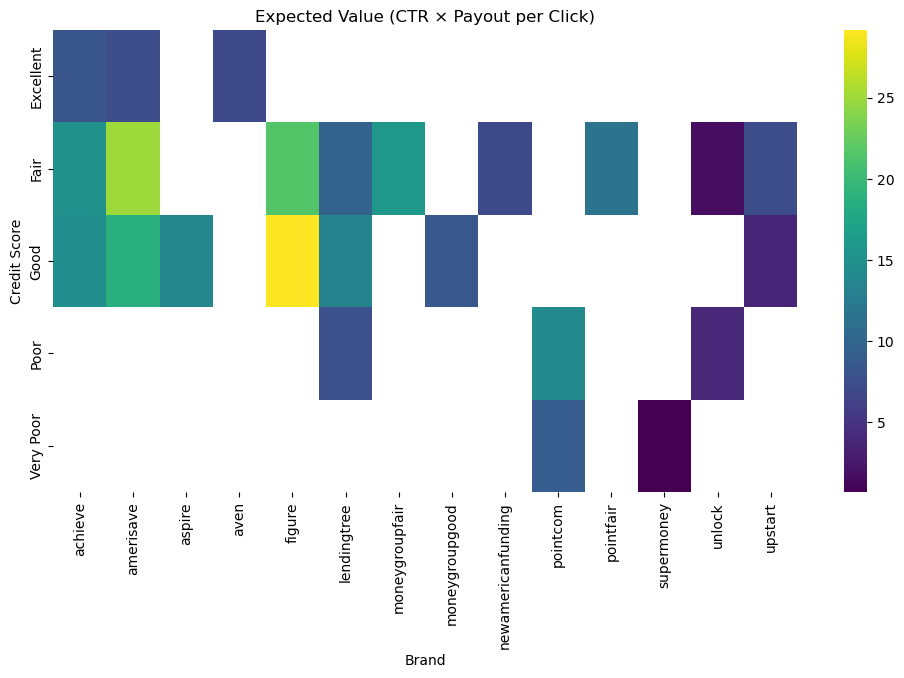

In [410]:
pivot_ev = agg.pivot(
    index="credit_score_rate",
    columns="brand",
    values="expected_value"
)

plt.figure(figsize=(12, 6))
sns.heatmap(pivot_ev, cmap="viridis")
plt.title("Expected Value (CTR × Payout per Click)")
plt.xlabel("Brand") 
plt.ylabel("Credit Score")
plt.show()

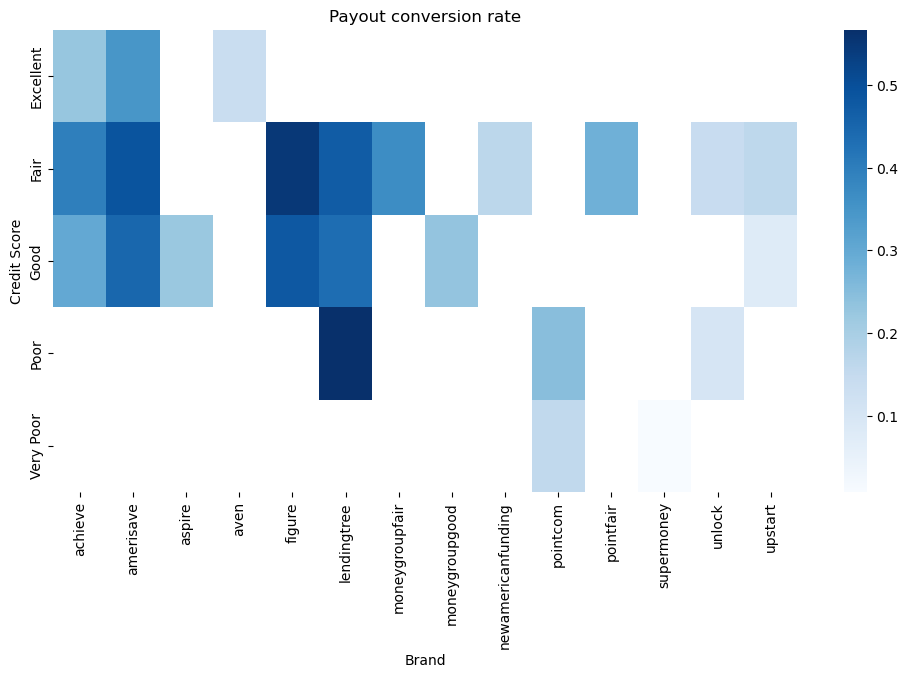

In [412]:
pivot_conv = agg.pivot(
    index="credit_score_rate",
    columns="brand",
    values="conv_rate_given_click"
)

plt.figure(figsize=(12, 6))
sns.heatmap(pivot_conv, cmap="Blues")
plt.title("Payout conversion rate")
plt.xlabel("Brand")
plt.ylabel("Credit Score")
plt.show()

Insights:

- Global trend: wealthier profiles have lower CTR
- Some brands target premium users and correspondingly pay more payout, for instance "Figure", while some of the brands vice versa for ex. "lendingtree"
- Most of the brands try to target average users with Good/Fair credit risk rate and often fail targeting wealthiest segment ("Excellent" rate), the expected value fall dramatically

## Acquisition level EDA

In [419]:
unique_sessions['traffic_source'].value_counts()

Index(['session_id', 'annual_income', 'credit_line', 'credit_score_rate',
       'currently_have_mortgage', 'loan_primary_purpose', 'military_veteran',
       'property_type', 'property_use', 'property_value', 'session_dt',
       'conversion_dt', 'conversion_payout', 'brand', 'vertical', 'account_id',
       'account_name', 'campaign_id', 'campaign_name', 'adset_id',
       'adset_name', 'ad_id', 'ad_name', 'traffic_source', 'page',
       'device_type', 'city', 'country', 'state', 'position', 'offer_click',
       'annual_income_ord', 'credit_score_ord', 'credit_line_ord',
       'property_value_ord'],
      dtype='object')

In [436]:
unique_sessions['adset_name'].nunique()

19

In [423]:
unique_sessions['campaign_name'].value_counts()

HELOC - 5890                             10396
58995                                     2143
HELOC - 5892                              1974
organic                                   1513
HELOC VA - 589888                         1019
58997                                      276
589911                                     174
589922                                     115
58998                                       78
589955                                      68
589933                                      53
Veterans - 589988                           35
20888                                        5
HELOC - 58946                                4
Unbranded - Top10us - Lifetime - 2029        1
Name: campaign_name, dtype: int64

In [421]:
unique_sessions['account_name'].value_counts()

PL - Schemathics    13393
Topusmoney           2942
organic              1513
HomeRemodel360          6
Name: account_name, dtype: int64

In [427]:
unique_sessions['traffic_source'].value_counts(dropna=False)

facebook    14271
tiktok       3155
organic      1448
google         74
Name: traffic_source, dtype: int64

In [429]:
source_agg = (
    unique_sessions.groupby(["traffic_source"])
    .apply(lambda x: pd.Series({
        "ctr": x["clicked"].mean(),
        "n": len(x),
        # conditional on click
        "conv_rate_given_click": x.loc[x["clicked"], "is_converted"].mean(),
        "payout_per_click": x.loc[x["clicked"], "payout_filled"].mean(),
        "payout_mean_converted": x.loc[x["is_converted"], "payout_filled"].mean()
        
    }))
    .reset_index()
)

source_agg["expected_value"] = source_agg["ctr"] * source_agg["payout_per_click"]

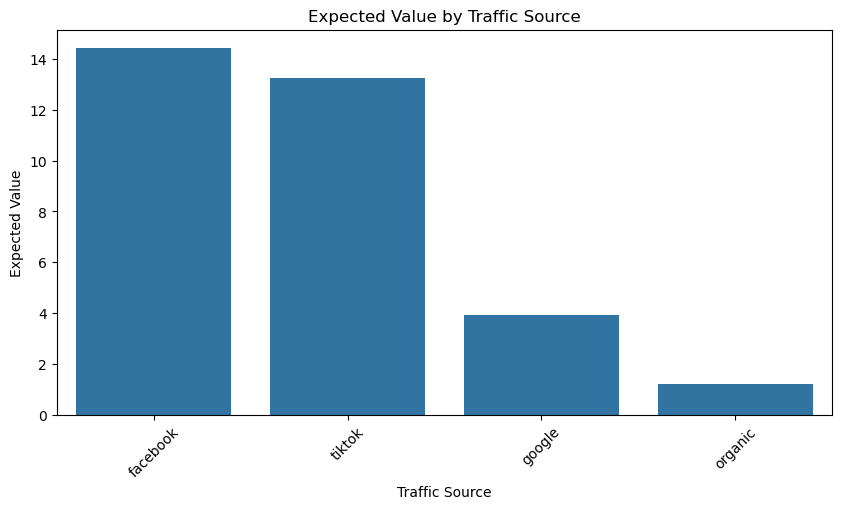

In [431]:
plt.figure(figsize=(10, 5))
sns.barplot(data=source_agg.sort_values("expected_value", ascending=False), x="traffic_source", y="expected_value")
plt.title("Expected Value by Traffic Source")
plt.ylabel("Expected Value")
plt.xlabel("Traffic Source")
plt.xticks(rotation=45)
plt.show()

FB ads is the most lucrative source in terms of expected value

- Could delve deeper, but have limited time

In [437]:
sessions.groupby('session_id')['brand'].count().rename('session_offer_count')

session_id
00041b27-c2f8-4978-b85d-c94e7d7b6d47    4
00046a33-3dd4-427d-bb3e-bb57f7640927    2
00056d96-c3b9-4b28-9180-14b93404b9db    4
0006b04a-753c-446d-bf8c-573cd6a326fb    5
000719bf-7095-4683-8d0e-ef2d64640bf8    4
                                       ..
fff4b331-e1ca-487e-830e-9fdd930e3f15    5
fff64a42-c8cc-4d21-ae2b-f3fa9214456f    6
fff7f6c5-2d05-4c0f-ba43-e79270035853    4
fffb0397-9c0b-414c-b4b9-b6e7cfea2b79    1
ffff7b19-2e31-499c-84c1-104eda098cc8    3
Name: session_offer_count, Length: 18948, dtype: int64

# Feature Engineering

In [556]:
# there are duplicate brands per one session with varying conversion dt timestamp
sessions_clean = (
    sessions
    .sort_values(['session_id', 'brand', 'position'])
    .drop_duplicates(subset=['session_id', 'brand'], keep='first')
    .reset_index(drop=True)
)

In [557]:
from sklearn.model_selection import GroupShuffleSplit

splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(sessions_clean, groups=sessions_clean['session_id']))

train = sessions_clean.iloc[train_idx].copy()
test  = sessions_clean.iloc[test_idx].copy()

print(train.shape)
print(test.shape)

(48382, 36)
(11956, 36)


In [558]:
train['session_id'].nunique(), test['session_id'].nunique()

(15158, 3790)

## Brand encoding

I want to encode some metrics we already used in EDA about brands as features, then lookup-s will be used on inference as well

In [559]:
# BRAND STATS

ALPHA = 10  # pseudo-count for smoothing to tackle cold start problem

train['payout_filled'] = train['conversion_payout'].fillna(0)

global_ctr = train['offer_click'].mean()

brand_stats = train.groupby('brand').agg(
    brand_clicks=('offer_click', 'sum'),
    brand_impressions=('offer_click', 'count'),
    brand_revenue=('payout_filled', 'sum'),
    brand_conversions=('conversion_payout', lambda x: x.notna().sum())
).reset_index()

brand_stats['brand_ctr'] = (brand_stats['brand_clicks'] + ALPHA * global_ctr)/(brand_stats['brand_impressions'] + ALPHA)

brand_stats['payout_per_click'] = brand_stats['brand_revenue'] / brand_stats['brand_clicks'].clip(lower=1)

brand_stats['brand_ev'] = brand_stats['brand_ctr'] * brand_stats['payout_per_click']

# Position-1  CTR
pos1 = train[train['position'] == 1].groupby('brand').agg(
    p1_clicks=('offer_click', 'sum'),
    p1_impressions=('offer_click', 'count')
).reset_index()
pos1['brand_pos1_ctr'] = (
    (pos1['p1_clicks'] + ALPHA * global_ctr) / (pos1['p1_impressions'] + ALPHA)
)
brand_stats = brand_stats.merge(pos1[['brand', 'brand_pos1_ctr']], on='brand', how='left')
brand_stats['brand_pos1_ctr'] = brand_stats['brand_pos1_ctr'].fillna(global_ctr)

brand_stats[['brand', 'brand_ctr', 'brand_ev', 'brand_pos1_ctr']].sort_values('brand_ev', ascending=False)

,brand,brand_ctr,brand_ev,brand_pos1_ctr
1,amerisave,0.370375,16.399245,0.377151
14,pointcom,0.665322,13.979520,0.671132
6,figure,0.193703,9.940515,0.425601
15,pointfair,0.371102,8.121079,0.546850
0,achieve,0.145992,4.156725,0.476141
21,upstart,0.328940,3.895723,0.558628
3,aspire,0.123712,3.866002,0.457649
4,aven,0.173709,3.523501,0.468273
13,newamericanfunding,0.182170,2.864866,0.466313
10,moneygroupfair,0.120363,2.803563,0.622860


In [592]:
# BRAND + CREDIT RATE STATS
ALPHA_CROSS = 10  

brand_credit = train.groupby(['brand', 'credit_score_ord']).agg(
    bc_clicks=('offer_click', 'sum'),
    bc_impressions=('offer_click', 'count')
).reset_index()

brand_credit = brand_credit.merge(brand_stats[['brand', 'brand_ctr']], on='brand', how='left')
brand_credit['brand_credit_ctr'] = (
    (brand_credit['bc_clicks'] + ALPHA_CROSS * brand_credit['brand_ctr']) /
    (brand_credit['bc_impressions'] + ALPHA_CROSS)
)
brand_credit['brand_credit_lift'] = (
    brand_credit['brand_credit_ctr'] / brand_credit['brand_ctr'].clip(lower=1e-6)
)

brand_credit = brand_credit[['brand', 'credit_score_ord', 'brand_credit_ctr', 'brand_credit_lift']]

In [560]:
# TRAFFIC SOURCE LOOKUPs
traffic_stats = train.groupby('traffic_source').agg(
    ts_clicks=('offer_click', 'sum'),
    ts_impressions=('offer_click', 'count'),
    ts_revenue=('payout_filled', 'sum'),
    ts_conversions=('conversion_payout', lambda x: x.notna().sum())
).reset_index()

traffic_stats['traffic_ctr'] = (
    (traffic_stats['ts_clicks'] + ALPHA * global_ctr) /
    (traffic_stats['ts_impressions'] + ALPHA)
)
traffic_stats['traffic_payout_perclick'] = (
    traffic_stats['ts_revenue'] / traffic_stats['ts_clicks'].clip(lower=1)
)
traffic_stats['traffic_ev'] = traffic_stats['traffic_ctr'] * traffic_stats['traffic_payout_perclick']

traffic_stats = traffic_stats[['traffic_source', 'traffic_ctr', 'traffic_ev']]

In [1085]:
# Save for inference pipeline later
import json

brand_lookup = (
    brand_stats[['brand', 'brand_ctr', 'brand_ev', 'brand_pos1_ctr']]
    .set_index('brand')
    .to_dict(orient='index')
)

brand_credit_lookup = {
    f"{row['brand']}|{int(row['credit_score_ord'])}": {
        'brand_credit_ctr': row['brand_credit_ctr'],
        'brand_credit_lift': row['brand_credit_lift']
    }
    for _, row in brand_credit.iterrows()
}

traffic_lookup = (
    traffic_stats.set_index('traffic_source')
    .to_dict(orient='index')
)

imputation_params = {
    'global_ctr': float(global_ctr),
    'income_median': float(income_median),
    'cline_median': float(cline_median),
    'credit_score_median': float(credit_score_median),
    'property_value_median': float(property_value_median),
}

for name, obj in [
    ('brand_lookup', brand_lookup),
    ('brand_credit_lookup', brand_credit_lookup),
    ('traffic_lookup', traffic_lookup),
    ('imputation_params', imputation_params),
]:
    with open(f'data/{name}.json', 'w') as f:
        json.dump(obj, f, indent=2)
    print(f"Saved data/{name}.json")

Saved data/brand_lookup.json
Saved data/brand_credit_lookup.json
Saved data/traffic_lookup.json
Saved data/imputation_params.json


### NAs

In [561]:
na_ratios = sessions.isna().sum()/sessions.shape[0]

na_ratios[na_ratios > 0].sort_values(ascending=False)

conversion_dt              0.926503
conversion_payout          0.926503
military_veteran           0.583361
annual_income              0.457198
annual_income_ord          0.457198
credit_line                0.411130
credit_line_ord            0.411130
ad_name                    0.145428
adset_name                 0.145428
campaign_name              0.145428
account_name               0.145428
account_id                 0.145428
city                       0.006977
state                      0.006977
property_type              0.004272
property_use               0.001946
loan_primary_purpose       0.001237
country                    0.001122
property_value             0.000891
property_value_ord         0.000891
credit_score_ord           0.000660
currently_have_mortgage    0.000610
dtype: float64

In [562]:
# Missing flags for high-na features
train['annual_income_missing'] = train['annual_income_ord'].isna().astype(int)
train['credit_line_missing'] = train['credit_line_ord'].isna().astype(int)
train['military_missing'] = train['military_veteran'].isna().astype(int)

test['annual_income_missing'] = test['annual_income_ord'].isna().astype(int)
test['credit_line_missing'] = test['credit_line_ord'].isna().astype(int)
test['military_missing'] = test['military_veteran'].isna().astype(int)

In [563]:
# Imputing user features with median values
income_median = train['annual_income_ord'].median()
cline_median = train['credit_line_ord'].median()
credit_score_median = train['credit_score_ord'].median()
property_value_median = train['property_value_ord'].median()

train['annual_income_ord'] = train['annual_income_ord'].fillna(income_median)
train['credit_line_ord'] = train['credit_line_ord'].fillna(cline_median)
train['credit_score_ord'] = train['credit_score_ord'].fillna(credit_score_median)
train['property_value_ord'] = train['property_value_ord'].fillna(property_value_median)

test['annual_income_ord']= test['annual_income_ord'].fillna(income_median)
test['credit_line_ord'] = test['credit_line_ord'].fillna(cline_median)
test['credit_score_ord'] = test['credit_score_ord'].fillna(credit_score_median)
test['property_value_ord'] = test['property_value_ord'].fillna(property_value_median)

In [564]:
sessions_clean['loan_primary_purpose'].value_counts()

Home Improvements           27396
Debt Consolidation          18274
Other                        8471
Investment Opportunities     3617
Retirement Income            2505
Name: loan_primary_purpose, dtype: int64

In [565]:
# Loan purpose onehot
purpose_dummies = pd.get_dummies(sessions_clean['loan_primary_purpose'], prefix='loan_purpose', drop_first=True)

train = pd.concat([train.reset_index(drop=True),
                   purpose_dummies.iloc[train_idx].reset_index(drop=True)], axis=1)

test = pd.concat([test.reset_index(drop=True),
                   purpose_dummies.iloc[test_idx].reset_index(drop=True)], axis=1)

In [566]:
# Device onehot
device_dummies = pd.get_dummies(sessions_clean['device_type'], prefix='device', drop_first=True)

train = pd.concat([train.reset_index(drop=True),
                   device_dummies.iloc[train_idx].reset_index(drop=True)], axis=1)
test  = pd.concat([test.reset_index(drop=True),
                   device_dummies.iloc[test_idx].reset_index(drop=True)], axis=1)

In [567]:
# Property type
ptype_dummies = pd.get_dummies(sessions_clean['property_type'], prefix='property_type', drop_first=True)

train = pd.concat([train.reset_index(drop=True),
                   ptype_dummies.iloc[train_idx].reset_index(drop=True)], axis=1)
test  = pd.concat([test.reset_index(drop=True),
                   ptype_dummies.iloc[test_idx].reset_index(drop=True)], axis=1)

In [568]:
# Property use 
puse_dummies = pd.get_dummies(sessions_clean['property_use'], prefix='property_use', drop_first=True)

train = pd.concat([train.reset_index(drop=True),
                   puse_dummies.iloc[train_idx].reset_index(drop=True)], axis=1)
test  = pd.concat([test.reset_index(drop=True),
                   puse_dummies.iloc[test_idx].reset_index(drop=True)], axis=1)

In [569]:
sessions['property_type'].value_counts(dropna=False)

Single-Family Home        53497
Townhome / Condominium     2938
Multi-Family Home          2115
Mobile Home                1819
NaN                         259
Name: property_type, dtype: int64

In [570]:
sessions['property_use'].value_counts(dropna=False)

Primary Residence          57310
Rental Property             2043
Secondary/Vacation Home     1157
NaN                          118
Name: property_use, dtype: int64

## Position features

There is option either to use position as a feature or not. We have position bias (showed within EDA), thats why decided to create position features to debias it

- During inference position will be just put as "1" so that we predict relevance for every brand as if they were all in the top spot

In [590]:
train['position_inv'] = 1.0 / train['position']
train['is_position_1'] = (train['position'] == 1).astype(int)

test['position_inv'] = 1.0 / test['position']
test['is_position_1'] = (test['position'] == 1).astype(int)

Merge stats we calculated above

In [593]:
brand_cols = ['brand', 'brand_ctr', 'brand_ev', 'brand_pos1_ctr']
traffic_cols = ['traffic_source', 'traffic_ctr', 'traffic_ev']

def enrich_features(df):
    df = df.merge(brand_stats[brand_cols], on='brand', how='left')
    df = df.merge(brand_credit, on=['brand', 'credit_score_ord'], how='left')
    df = df.merge(traffic_stats[traffic_cols], on='traffic_source', how='left')
    
    df['brand_credit_ctr'] = df['brand_credit_ctr'].fillna(df['brand_ctr'])
    df['brand_credit_lift'] = df['brand_credit_lift'].fillna(1.0)
    
    return df

train = enrich_features(train)
test = enrich_features(test)

KeyError: 'brand_credit_ctr'

In [573]:
train.shape, test.shape

((48382, 60), (11956, 59))

In [574]:
train.columns

Index(['session_id', 'annual_income', 'credit_line', 'credit_score_rate',
       'currently_have_mortgage', 'loan_primary_purpose', 'military_veteran',
       'property_type', 'property_use', 'property_value', 'session_dt',
       'conversion_dt', 'conversion_payout', 'brand', 'vertical', 'account_id',
       'account_name', 'campaign_id', 'campaign_name', 'adset_id',
       'adset_name', 'ad_id', 'ad_name', 'traffic_source', 'page',
       'device_type', 'city', 'country', 'state', 'position', 'offer_click',
       'annual_income_ord', 'credit_score_ord', 'credit_line_ord',
       'property_value_ord', 'mortgage_ord', 'payout_filled',
       'annual_income_missing', 'credit_line_missing', 'military_missing',
       'loan_purpose_Home Improvements',
       'loan_purpose_Investment Opportunities', 'loan_purpose_Other',
       'loan_purpose_Retirement Income', 'device_mobile', 'device_tablet',
       'property_type_Multi-Family Home', 'property_type_Single-Family Home',
       'property_

In [470]:
sessions.head(1)

,session_id,annual_income,credit_line,credit_score_rate,currently_have_mortgage,loan_primary_purpose,military_veteran,property_type,property_use,property_value,session_dt,conversion_dt,conversion_payout,brand,vertical,account_id,account_name,campaign_id,campaign_name,adset_id,adset_name,ad_id,ad_name,traffic_source,page,device_type,city,country,state,position,offer_click,annual_income_ord,credit_score_ord,credit_line_ord,property_value_ord
20995,00041b27-c2f8-4978-b85d-c94e7d7b6d47,$50K–$75K,Maximum Eligible,Good,$250K-$400K,Home Improvements,Yes,Single-Family Home,Primary Residence,"$400,000 - $600,000",2025-10-30T01:21:30.000Z,NaN,NaN,amerisave,Home Equity Loans,332412632590552,PL - Schemathics,120235148710520617,HELOC VA - 589888,120235148710560617,VA,120235893179790617,6221123795,facebook,https://top10us.com/app/heloc-v5,mobile,South Bend,United States,Indiana,1,0,2.0,4.0,6.0,3.0


In [576]:
train['is_military'] = (train['military_veteran'] == 'Yes').astype(int)
test['is_military'] = (test['military_veteran'] == 'Yes').astype(int)

In [1279]:
feature_cols = [
     'position',
     'position_inv',
     'is_position_1',
     'brand_ctr',
     'brand_ev',
     'brand_pos1_ctr',
     'brand_credit_ctr',
     'brand_credit_lift',
     'credit_score_ord',
     'annual_income_ord',
     'annual_income_missing',
     'credit_line_ord',
     'credit_line_missing',
     'property_value_ord',
     'mortgage_ord',
     'military_missing',
     'is_military',
     'traffic_ctr',
     'traffic_ev',
     'loan_purpose_Home Improvements',
     'loan_purpose_Investment Opportunities',
     'loan_purpose_Other',
     'loan_purpose_Retirement Income',
     'device_mobile',
     'device_tablet',
     'property_type_Multi-Family Home',
     'property_type_Single-Family Home',
     'property_type_Townhome / Condominium',
     'property_use_Rental Property',
     'property_use_Secondary/Vacation Home'
]

len(set(feature_cols))

30

In [598]:
# Just to make sure 
nuniques = train[feature_cols].nunique()

nuniques[nuniques < 2]

Series([], dtype: int64)

In [606]:
nuniques

position                                  7
position_inv                              7
is_position_1                             2
brand_ctr                                21
brand_ev                                 18
brand_pos1_ctr                           20
brand_credit_ctr                         66
brand_credit_lift                        54
credit_score_ord                          5
annual_income_ord                         4
annual_income_missing                     2
credit_line_ord                           5
credit_line_missing                       2
property_value_ord                        5
mortgage_ord                              5
military_missing                          2
is_military                               2
traffic_ctr                               4
traffic_ev                                4
loan_purpose_Home Improvements            2
loan_purpose_Investment Opportunities     2
loan_purpose_Other                        2
loan_purpose_Retirement Income  

Not using some features because of too much cardinality and drift is too likely (city, ad params etc.) and some feature are just almost constant and have no sense to use for training

# Modelling

This is a classic Learning-to-rank problem, where the boosting models on tabular data (especially with limited data like here) show the best performance. 

- We are not predicting just CTR, we want to maximize the expected value: ev = P(click|user, brand) * E(payout|click, user, brand)

- traditionally there are 3 ways of LTR: poinwise (almost the same as regression/classification), pairwise & listwise

For now lets focus on pairwise & listwise approaches since we have limited time and we want the most promising methods within the short time

## Metrics

We will stick to:

- NDCG - Normalized Discounted Cumulative Gain, compares rankings to an ideal order where all relevant items are at the top of the list. A metric that takes into account both relevance (offer click & payout) and order by using discount that gives less weight to relevant items that appear lower. 
- MRR (Mean Reciprocal Rank ) - in a nutshell is an average position of the first relevant item across all user lists
- EV@k - sum of the payouts at top k
- CTR@k - click conversion rate at top k

ML models to try:

- Catboost 
- XGBoost

both pairwise & listwise

### Current metrics

In [1167]:
# We use mrr, ndcg@k and sum of the payouts per top3 positions as metrics

def calculate_ranking_metrics_aligned(df, score_col, rel_col='relevance', k=5):
    metrics = []
    
    def get_dcg_exp(rel_values):
        gains = (2**rel_values - 1)
        discounts = np.log2(np.arange(2, len(rel_values) + 2))
        return np.sum(gains / discounts)

    for session_id, group in df.groupby('session_id'):
        # Sort by the specific score (ascending=False if it's a model score)
        ascending = True if score_col == 'position' else False
        group = group.sort_values(score_col, ascending=ascending).reset_index(drop=True)
        
        # Get the top K relevance values
        rel_at_k = group[rel_col].values[:k]
        
        positive_idx = np.where(rel_at_k > 0)[0]
        mrr = 1 / (positive_idx[0] + 1) if len(positive_idx) > 0 else 0
        
        actual_dcg = get_dcg_exp(rel_at_k)
        
        ideal_labels = np.sort(group[rel_col].values)[::-1][:k]
        idcg = get_dcg_exp(ideal_labels)
        
        ndcg = (actual_dcg / idcg) if idcg > 0 else 0
                
        metrics.append({
            'mrr': mrr,
            'ndcg': ndcg
        })

    return pd.DataFrame(metrics).mean()

In [842]:
# Take into account only session where was some interaction for more reasonable evaluation
has_click = sessions_clean.groupby('session_id')['offer_click'].sum()

# Get a list of interested session that will be used in evaluation
clicked_sessions = has_click[has_click > 0].index

# Df with sessions that have at least one click
sessions_click_df = sessions_clean[sessions_clean['session_id'].isin(clicked_sessions)].sort_values(by=['session_id', 'position'])

In [1087]:
len(clicked_sessions)

12316

In [916]:
train_clicked = train[train['session_id'].isin(clicked_sessions)].sort_values(by=['session_id', 'position']).reset_index(drop=True)

test_clicked = test[test['session_id'].isin(clicked_sessions)].sort_values(by=['session_id', 'position']).reset_index(drop=True)

In [1101]:
# 1 if clicked + log1p payout if the payout happened

def make_relevance(df):
    rel = np.zeros(len(df), dtype=int)
    payouts = df['conversion_payout'].fillna(0)
    rel[df['offer_click'].values == 1] = 1
    rel += np.log1p(payouts)
    return rel

train_clicked['relevance'] = make_relevance(train_clicked)
test_clicked['relevance'] = make_relevance(test_clicked)

train_clicked['relevance'].value_counts()

0    19479
1     7225
5     1981
4      847
7       78
6       47
Name: relevance, dtype: int64

In [1168]:
# We use mrr, ndcg@k and sum of the payouts per top3 positions as metrics
calculate_ranking_metrics_aligned(train_clicked, 'position', 'relevance', k=3)

mrr     0.851616
ndcg    0.875887
dtype: float64

In [1102]:
len(set(train['session_id'].unique()).intersection(set(clicked_sessions))), len(set(test['session_id'].unique()).intersection(set(clicked_sessions)))

(9809, 2507)

In [1103]:
# Create validation set additionally
val_splitter = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=0)
tr_idx, val_idx = next(val_splitter.split(train_clicked, groups=train_clicked['session_id']))

train_tr = train_clicked.iloc[tr_idx].sort_values('session_id').reset_index(drop=True)
val = train_clicked.iloc[val_idx].sort_values('session_id').reset_index(drop=True)

test_s = test_clicked.sort_values('session_id').reset_index(drop=True)

train_tr['session_id'].nunique(), val['session_id'].nunique()

(8337, 1472)

In [1163]:
from catboost import CatBoostRanker, Pool

def make_pool(df):
    return Pool(
        data=df[feature_cols],
        label=df['relevance'],
        group_id=df['session_id']
    )

pool_tr = make_pool(train_tr)
pool_val = make_pool(val)
#pool_test = make_pool(test_s)

pool_test = Pool(
        data=test_s[feature_cols],
        #label=df['relevance'],
        group_id=test_s['session_id']
    )

In [1280]:
import xgboost as xgb

def make_dmatrix(df):
    groups = df.groupby('session_id', sort=False)['session_id'].count().values
    dmat = xgb.DMatrix(df[feature_cols], label=df['relevance'])
    dmat.set_group(groups)
    return dmat

dmat_tr = make_dmatrix(train_tr)
dmat_val = make_dmatrix(val)
dmat_test = make_dmatrix(test_s)

## Pairwise

optimizes via pair comparisons

In [1170]:
cb_pair = CatBoostRanker(
    loss_function='YetiRankPairwise',
    eval_metric='NDCG:top=3',
    iterations=1000,
    learning_rate=0.001,
    depth=6,
    random_seed=42,
    early_stopping_rounds=200,
    verbose=100
)
cb_pair.fit(pool_tr, eval_set=pool_val)

0:	test: 0.8722648	best: 0.8722648 (0)	total: 18.5ms	remaining: 18.4s
100:	test: 0.8747316	best: 0.8749520 (73)	total: 1.57s	remaining: 14s
200:	test: 0.8742726	best: 0.8750713 (105)	total: 3.12s	remaining: 12.4s
300:	test: 0.8748206	best: 0.8751602 (260)	total: 4.68s	remaining: 10.9s
400:	test: 0.8743920	best: 0.8751602 (260)	total: 6.19s	remaining: 9.25s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 0.8751602487
bestIteration = 260

Shrink model to first 261 iterations.


CatBoostRanker(depth=6, early_stopping_rounds=200, eval_metric='NDCG:top=3', iterations=1000, learning_rate=0.001, loss_function='YetiRankPairwise', random_seed=42, verbose=100)

In [1290]:
xgb_pair_params = {
    'objective': 'rank:pairwise',
    'eval_metric': 'ndcg@3',
    'eta': 1e-3,
    'max_depth': 6,
    'seed': 42,
}
xgb_pair = xgb.train(
    xgb_pair_params,
    dmat_tr,
    num_boost_round=1000,
    evals=[(dmat_tr, 'train'), (dmat_val, 'val')],
    early_stopping_rounds=50,
    verbose_eval=100
)

[0]	train-ndcg@3:0.88565	val-ndcg@3:0.87770
[70]	train-ndcg@3:0.88663	val-ndcg@3:0.87811


## Listwise

Uses the whole list for optimization

In [1172]:
cb_list = CatBoostRanker(
    loss_function='YetiRank', # approaximates ndcg
    eval_metric='NDCG:top=3',
    iterations=1000,
    learning_rate=1e-3,
    depth=6,
    random_seed=42,
    early_stopping_rounds=300,
    verbose=100
)
cb_list.fit(pool_tr, eval_set=pool_val)

0:	test: 0.8691813	best: 0.8691813 (0)	total: 12.9ms	remaining: 12.9s
100:	test: 0.8764991	best: 0.8794267 (26)	total: 974ms	remaining: 8.67s
200:	test: 0.8764445	best: 0.8794267 (26)	total: 1.98s	remaining: 7.86s
300:	test: 0.8767842	best: 0.8794267 (26)	total: 3.14s	remaining: 7.28s
Stopped by overfitting detector  (300 iterations wait)

bestTest = 0.8794267372
bestIteration = 26

Shrink model to first 27 iterations.


CatBoostRanker(depth=6, early_stopping_rounds=300, eval_metric='NDCG:top=3', iterations=1000, learning_rate=0.001, loss_function='YetiRank', random_seed=42, verbose=100)

In [1173]:
xgb_list_params = {
    'objective': 'rank:ndcg',
    'eval_metric': 'ndcg@3',
    'eta': 1e-3,
    'max_depth': 6,
    'seed': 42,
}
xgb_list = xgb.train(
    xgb_list_params,
    dmat_tr,
    num_boost_round=1000,
    evals=[(dmat_tr, 'train'), (dmat_val, 'val')],
    early_stopping_rounds=200,
    verbose_eval=100
)

[0]	train-ndcg@3:0.88486	val-ndcg@3:0.87799
[100]	train-ndcg@3:0.88710	val-ndcg@3:0.87758
[200]	train-ndcg@3:0.88749	val-ndcg@3:0.87904
[300]	train-ndcg@3:0.88794	val-ndcg@3:0.87835
[400]	train-ndcg@3:0.88809	val-ndcg@3:0.87810
[417]	train-ndcg@3:0.88809	val-ndcg@3:0.87816


In [1175]:
test_s['cb_pair_score'] = cb_pair.predict(pool_test)
test_s['cb_list_score'] = cb_list.predict(pool_test)

test_s['xgb_pair_score'] = xgb_pair.predict(dmat_test)
test_s['xgb_list_score'] = xgb_list.predict(dmat_test)

In [1176]:
def evaluate_models(df, model_cols, k=3):
    """
    Evaluate multiple ranking score columns and return comparison DataFrame
    """
    results = []

    for col in model_cols:
        metrics = calculate_ranking_metrics_aligned(df, col, 'relevance', k)
        metrics = metrics.to_dict()
        metrics['model'] = col
        results.append(metrics)

    results_df = pd.DataFrame(results)

    # reorder columns
    cols = ['model'] + [c for c in results_df.columns if c != 'model']
    results_df = results_df[cols]

    return results_df.sort_values('ndcg', ascending=False).reset_index(drop=True)

In [1210]:
# Current
calculate_ranking_metrics_aligned(test_s, 'position', 'relevance', k=3)

mrr     0.843704
ndcg    0.871876
dtype: float64

In [1178]:
model_cols = [
    'cb_pair_score',
    'cb_list_score',
    'xgb_pair_score',
    'xgb_list_score'
]

results_df = evaluate_models(test_s, model_cols, k=3)

results_df

,model,mrr,ndcg
0,xgb_pair_score,0.848291,0.876346
1,xgb_list_score,0.848424,0.876287
2,cb_list_score,0.846829,0.874954
3,cb_pair_score,0.842109,0.868200


From the default setup model we got a bit better metrics from the xgboost ranking model than in the current implementation. 
- Pairwise showed a bit better results possibly becasue 98% of the session are either 0 or 1 click, sparse payout signal, small dataset, however we'll check anyway on tuning


Let's focus on xgboost model since it shows the most prospering results

Now let's try to tune the model 

## Tuning
We usually separate tunings of the:

- tree specific params 
- learning params 

- we tune within groupkfold to ensure more fair results
- In order to speed up tuning & training we use bayesian search for tuning in large spaces

### Tree specific + loss

Tune tree specific params, mostly help to reguralize

Tune by ndcg, only 50 iterations since we have limited time

In [1186]:
def objective_xgb(trial):
    params = {
        "objective": trial.suggest_categorical("objective", ["rank:pairwise", "rank:ndcg"]),
        "eval_metric": "ndcg@3",I
        "learning_rate": 1e-3,
        "max_depth": trial.suggest_int("max_depth", 4, 8),
        "min_child_weight": trial.suggest_float("min_child_weight", 1, 50),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "lambda": trial.suggest_float("lambda", 1, 50, log=True),
        "alpha": trial.suggest_float("alpha", 1e-3, 10, log=True),
        "random_state": 42,
        "verbosity": 0,
    }

    gkf = GroupKFold(n_splits=4)
    ndcg_scores = []

    for tr_i, val_i in gkf.split(train_clicked, groups=train_clicked['session_id']):
        fold_tr = train_clicked.iloc[tr_i].sort_values('session_id').reset_index(drop=True)
        fold_val = train_clicked.iloc[val_i].sort_values('session_id').reset_index(drop=True)

        dtrain = make_dmatrix(fold_tr)
        dvalid = make_dmatrix(fold_val)

        model = xgb.train(
            params,
            dtrain,
            num_boost_round=1000,
            evals=[(dvalid, "validation")],
            early_stopping_rounds=100,
            verbose_eval=False
        )

        fold_val['score'] = model.predict(dvalid)

        metrics = calculate_ranking_metrics_aligned(fold_val, 'score', 'relevance', k=3)
        ndcg_scores.append(metrics['ndcg'])

    return np.mean(ndcg_scores)

In [ ]:
import optuna

study = optuna.create_study(
    direction="maximize",
    study_name="xgb_ranking",
)

study.optimize(
    objective_xgb,
    n_trials=50,
    n_jobs=5,  
    show_progress_bar=True
)

In [1191]:
# Tree specific params
best_tree_params = study.best_params

best_tree_params

{'objective': 'rank:ndcg',
 'max_depth': 8,
 'min_child_weight': 22.58233084860648,
 'subsample': 0.9819262315076671,
 'colsample_bytree': 0.9357127896886623,
 'lambda': 9.71364598262585,
 'alpha': 0.08057896823531621}

In [1192]:
study.best_value

0.8839484746303292

### Learning specific params

In [1193]:
def objective_lr(trial):
    params = best_tree_params.copy()

    # Tune ONLY learning dynamics
    params["learning_rate"] = trial.suggest_float("learning_rate", 0.01, 0.1, log=True)
    num_boost_round = trial.suggest_int("num_boost_round", 300, 2000)

    gkf = GroupKFold(n_splits=4)
    scores = []

    for tr_i, val_i in gkf.split(train_clicked, groups=train_clicked['session_id']):
        fold_tr = train_clicked.iloc[tr_i].sort_values('session_id').reset_index(drop=True)
        fold_val = train_clicked.iloc[val_i].sort_values('session_id').reset_index(drop=True)

        dtrain = make_dmatrix(fold_tr)
        dvalid = make_dmatrix(fold_val)

        model = xgb.train(
            params,
            dtrain,
            num_boost_round=num_boost_round,
            evals=[(dvalid, "validation")],
            early_stopping_rounds=100,
            verbose_eval=False
        )

        fold_val['score'] = model.predict(dvalid)

        metrics = calculate_ranking_metrics_aligned(
            fold_val,
            'score',
            'relevance',
            k=3
        )

        scores.append(metrics['ndcg'])  # or EV if you prefer

    return np.mean(scores)

In [1197]:
import optuna

study2 = optuna.create_study(
    direction="maximize",
    study_name="xgb_lrranking",
)

# 50 More for learning tuning
study2.optimize(
    objective_lr,
    n_trials=50,
    n_jobs=5,  
    show_progress_bar=True
)

[I 2026-03-25 23:33:06,631] A new study created in memory with name: xgb_lrranking
  0%|                                                        | 0/50 [00:04<?, ?it/s]

[I 2026-03-25 23:33:11,628] Trial 0 finished with value: 0.882253433037011 and parameters: {'learning_rate': 0.09623981255733782, 'num_boost_round': 987}. Best is trial 0 with value: 0.882253433037011.


  0%|                                                        | 0/50 [00:10<?, ?it/s]

[I 2026-03-25 23:33:16,912] Trial 2 finished with value: 0.8825780972726953 and parameters: {'learning_rate': 0.0758634394838297, 'num_boost_round': 581}. Best is trial 2 with value: 0.8825780972726953.


  0%|                                                        | 0/50 [00:13<?, ?it/s]

...

[I 2026-03-25 23:36:09,052] Trial 46 finished with value: 0.8833571861322305 and parameters: {'learning_rate': 0.016341789154472885, 'num_boost_round': 825}. Best is trial 15 with value: 0.8838519496164743.


Best trial: 15. Best value: 0.883852:  98%|████████▊| 49/50 [03:05<00:02,  2.67s/it]

[I 2026-03-25 23:36:12,392] Trial 48 finished with value: 0.8837687590878199 and parameters: {'learning_rate': 0.014038084489989385, 'num_boost_round': 883}. Best is trial 15 with value: 0.8838519496164743.


Best trial: 15. Best value: 0.883852: 100%|█████████| 50/50 [03:08<00:00,  3.76s/it]

[I 2026-03-25 23:36:14,703] Trial 49 finished with value: 0.8835798491892486 and parameters: {'learning_rate': 0.013348364808826204, 'num_boost_round': 1153}. Best is trial 15 with value: 0.8838519496164743.


In [1198]:
study2.best_params

{'learning_rate': 0.010136406557610127, 'num_boost_round': 1055}

In [1199]:
study2.best_value

0.8838519496164743

## Tuned model

In [1272]:
import xgboost as xgb

def make_dmatrix(df):
    groups = df.groupby('session_id', sort=False)['session_id'].count().values
    dmat = xgb.DMatrix(df[feature_cols], label=df['relevance'])
    dmat.set_group(groups)
    return dmat

dmat_tr = make_dmatrix(train_tr)
dmat_val = make_dmatrix(val)
dmat_test = make_dmatrix(test_s)

In [1311]:
xgb_final_params = {
    'objective': 'rank:ndcg@5',
     'max_depth': 8,
     'min_child_weight': 20,
     'subsample': 0.99,
     'colsample_bytree': 0.9,
     'lambda': 10,
     'alpha': 0.08,
     'eta': 0.01
}

xgb_final = xgb.train(
    xgb_pair_params,
    dmat_tr,
    num_boost_round=1000,
    evals=[(dmat_tr, 'train'), (dmat_val, 'val')],
    early_stopping_rounds=200,
    verbose_eval=50
)

[0]	train-ndcg@3:0.88565	val-ndcg@3:0.87770
[50]	train-ndcg@3:0.88678	val-ndcg@3:0.87760
[100]	train-ndcg@3:0.88665	val-ndcg@3:0.87842
[150]	train-ndcg@3:0.88728	val-ndcg@3:0.87867
[200]	train-ndcg@3:0.88735	val-ndcg@3:0.87817
[250]	train-ndcg@3:0.88765	val-ndcg@3:0.87735
[300]	train-ndcg@3:0.88810	val-ndcg@3:0.87810
[326]	train-ndcg@3:0.88810	val-ndcg@3:0.87810


In [1283]:
fi = xgb_final.get_score(importance_type='weight')

# Convert to DataFrame
fi_df = (
    pd.DataFrame({
        'feature': list(fi.keys()),
        'importance': list(fi.values())
    })
    .sort_values('importance', ascending=False)
)

print(fi_df)

                                  feature  importance
4                        brand_credit_ctr      1453.0
1                               brand_ctr      1334.0
7                       annual_income_ord      1244.0
2                                brand_ev      1145.0
5                       brand_credit_lift      1102.0
0                                position      1020.0
11                     property_value_ord      1003.0
21                          device_mobile       938.0
9                         credit_line_ord       886.0
12                           mortgage_ord       664.0
26   property_use_Secondary/Vacation Home       646.0
8                   annual_income_missing       584.0
15                            traffic_ctr       570.0
22                          device_tablet       555.0
13                       military_missing       542.0
6                        credit_score_ord       500.0
17         loan_purpose_Home Improvements       466.0
16                          

In [1315]:
xgb_final.save_model("data/xgb.json")

test_s['xgb_final_score'] = xgb_final.predict(dmat_test)

In [1286]:
# Current
calculate_ranking_metrics_aligned(test_s, 'position', 'relevance', k=3)

mrr     0.843704
ndcg    0.871876
dtype: float64

In [1308]:
# XGB
calculate_ranking_metrics_aligned(test_s, 'xgb_final_score', 'relevance', k=3)

mrr     0.847760
ndcg    0.875358
dtype: float64

We got slighly bettter results however tuning didn't help us a lot, likely due to low exploration

## Conclusion

EDA showed that

- Position bias: the first position receives nearly 50% CTR, while others disproportionally much lower. It might mean that clicks are influenced by position rather than offer quality/user preferences. It should be taken into consideration during modelling
- 98% of the sessions have either zero or one click, while the maximum number of clicks per session is 4
- there are duplicate brands per one session with varying conversion dt timestamp
- There are cases with several clicks and different payouts per one session (So several levels of relevance should be created later)

- 8 long tail brands that conributed to less that 1% of the traffic
- Some of the brands like "lendingtree" have significantly lower avg position (3.13), however show top performing ctr on positions number 1
- While some of the brands vice versa, have lower than median ctr on position number 1, but have higher avg position, for instance "figure"

- Global trend: wealthier profiles have lower CTR
- Some brands target premium users and correspondingly pay more payout, for instance "Figure", while some of the brands vice versa for ex. "lendingtree"
- Most of the brands try to target average users with Good/Fair credit risk rate and often fail targeting wealthiest segment ("Excellent" rate), the expected value fall dramatically

The main challenges were limited data for training and position bnias, even though the catboost models showed better performance according to offline metrics, the primary source of truth will be **online** metrics (during online experiments)

I did have limited time so lots of things were not tried or done not in the usual depth, 
for instance I might spend more time on position bias and trying things like **position bias learning frameworks** etc.

**Deployment**

I don't know your infrastucture and tech stack, I am comfortable deploying to both cloud service and self-hosted env-s, but for now I decided to stick to more popular way: deploying to kubernetes.

- For deployment I propose:

- k8s (kuber)
- FastAPI framework for web-service since it's faster than Flask, supports async
- otel_collector for metrics collection
- prometheus as the metrics storage that will be potentially connected to Grafana
otel + prometheus + grafana is the most popular monitoring combo out of my experience

- if I was monitoring that service, I'd use additionally evidently for data drifts detection


For deployment the following workflow would be used:

- potentially push saved model and pipeline artifacts to some kind of cloud storage like aws s3
- run local tests
- build docker image and push to ecr
- deploy yaml to corresponding repo with k8s on dev 
- check if everything works on dev/preprod
- then deploy to prod env